## Fase 2 (inicio del laboratorio programado)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
## configuracion de grafos

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
## carga de csv
## lectura del archivo

df = pd.read_csv("../data/adult.csv")

In [4]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
## dimension del data set 

print("Filas y columnas:")
print(df.shape)

Filas y columnas:
(32561, 15)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

### sección del EDA

In [9]:
## cantidad de datos duplicados 

print("Duplicados:", df.duplicated().sum())

Duplicados: 24


In [10]:
## eliminacion de duplicados 
df = df.drop_duplicates()

In [11]:
## verificacion posterior 
print("Nuevo tamaño del dataset:")
print(df.shape)

Nuevo tamaño del dataset:
(32537, 15)


In [12]:
## Analisis de la variable objetivo 

df["income"].value_counts()

income
<=50K    24698
>50K      7839
Name: count, dtype: int64

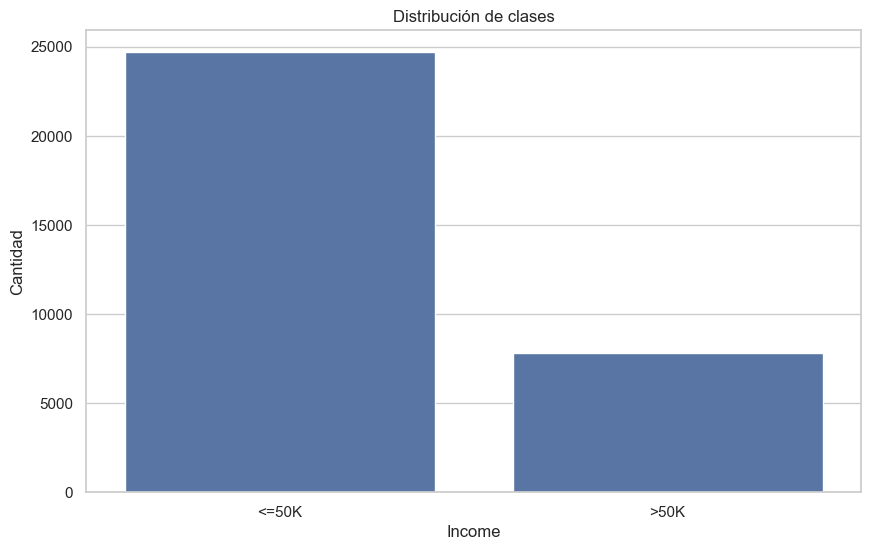

In [13]:
## visualizacion de clases 

sns.countplot(data=df, x="income")

plt.title("Distribución de clases")
plt.xlabel("Income")
plt.ylabel("Cantidad")

plt.show()

### Selección y análisis del dataset

In [14]:
## Análisis de variables numéricas
## Selección de variables numéricas

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

print(numeric_columns)

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')


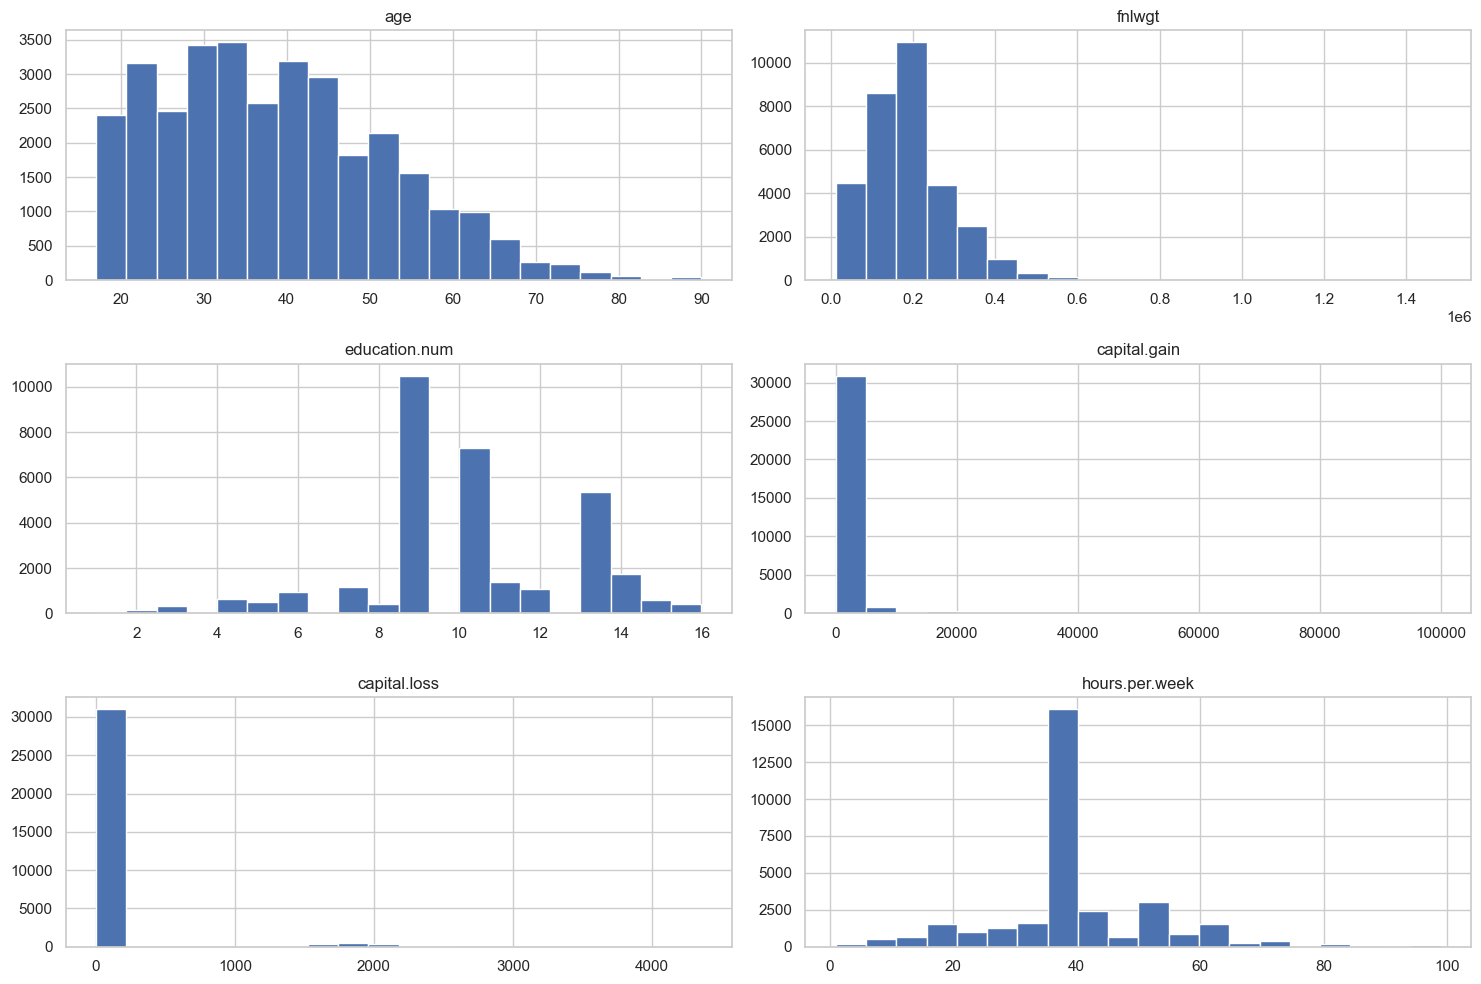

In [15]:
## Visualización de distribuciones numéricas
df[numeric_columns].hist(
    bins=20,
    figsize=(15,10)
)

plt.tight_layout()
plt.show()

In [16]:
## Estadísticas descriptivas de variables numéricas

df[numeric_columns].describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


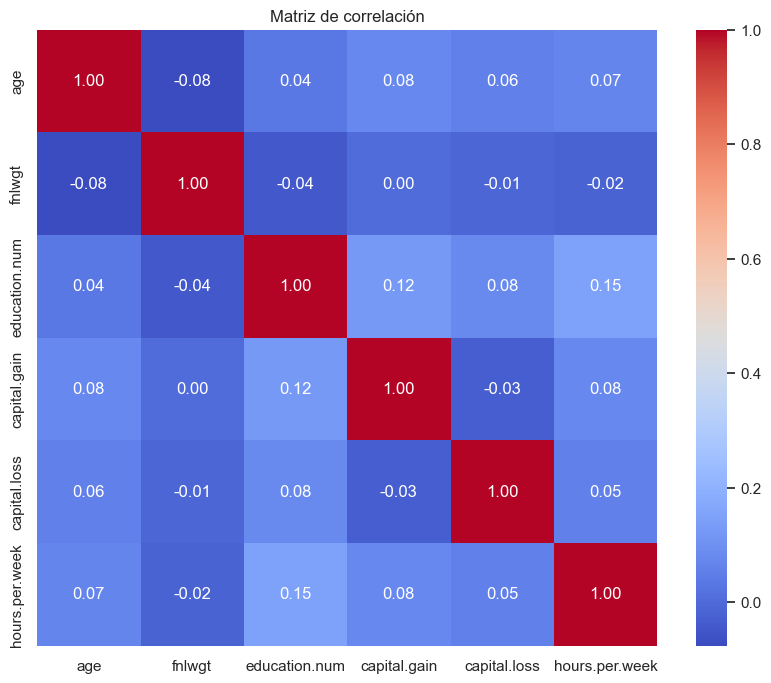

In [17]:
## Matriz de correlación

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Matriz de correlación")
plt.show()

In [18]:
## Selección de variables categóricas

categorical_columns = df.select_dtypes(include=['object']).columns

print(categorical_columns)

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='object')


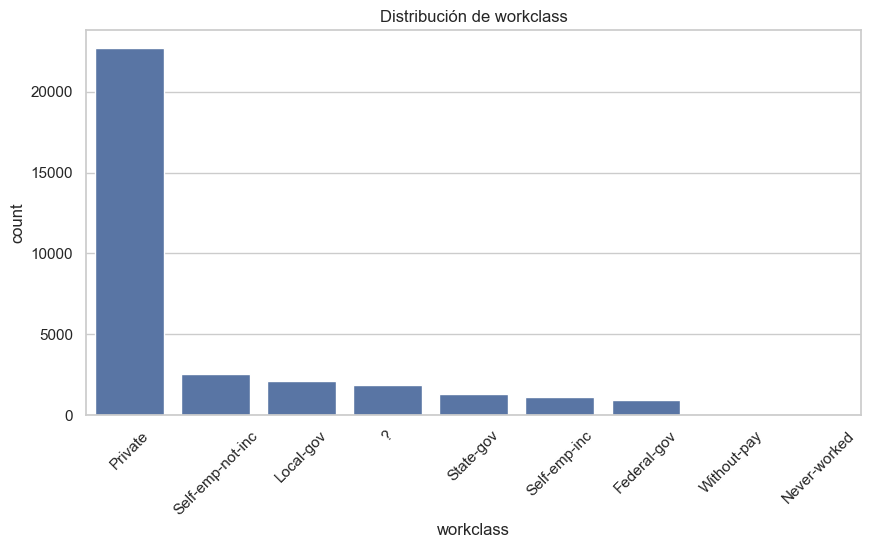

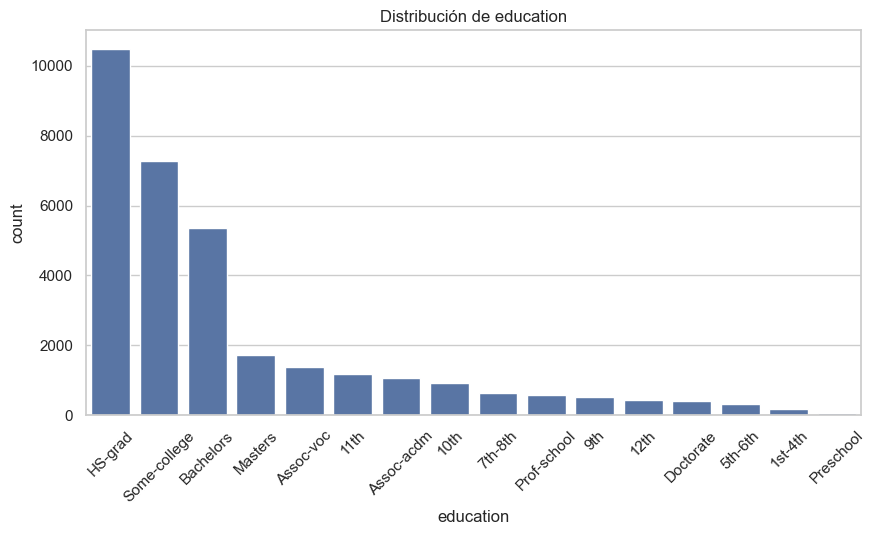

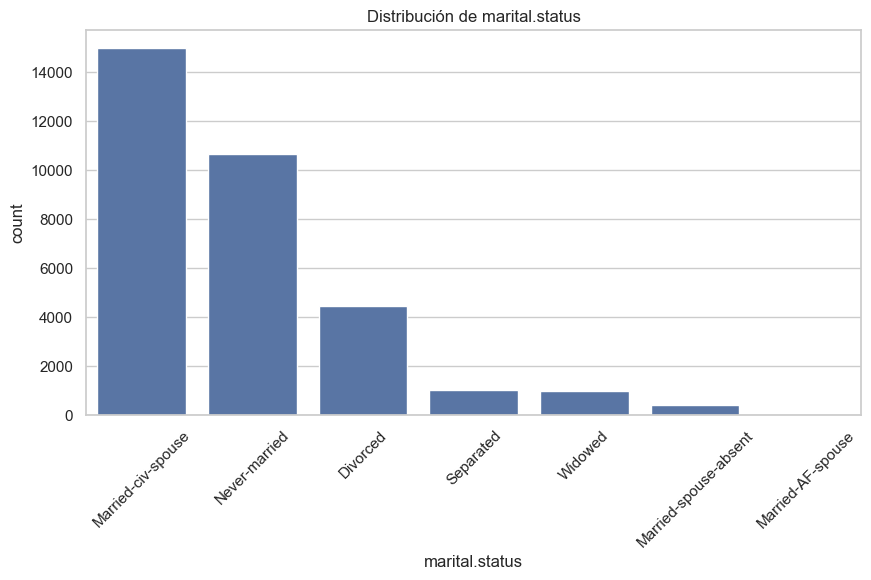

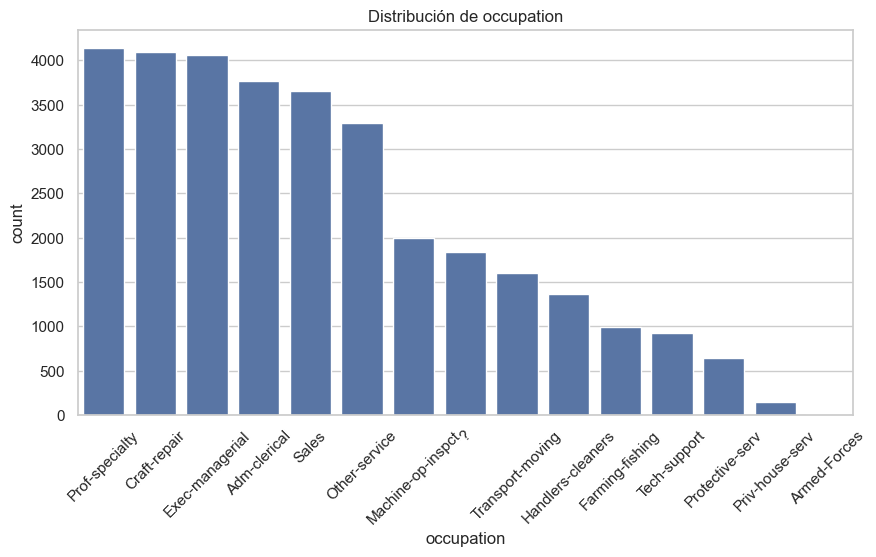

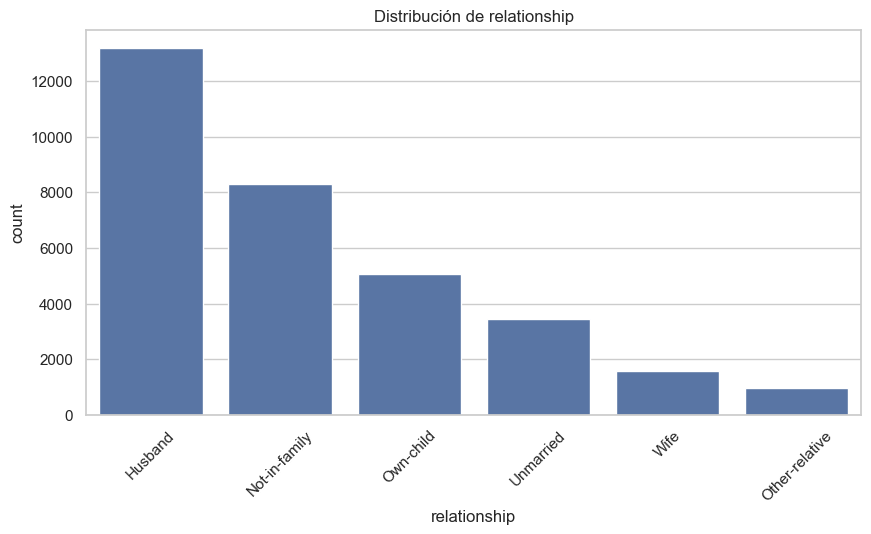

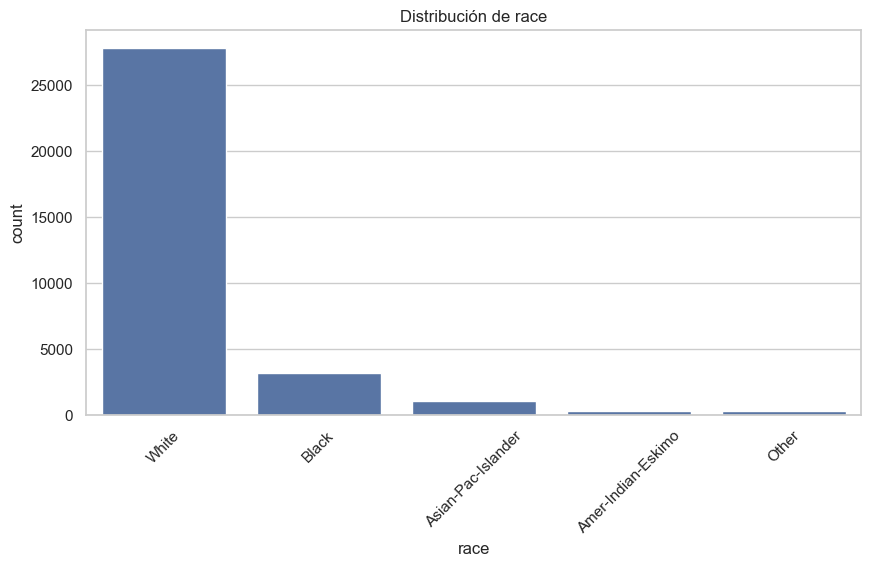

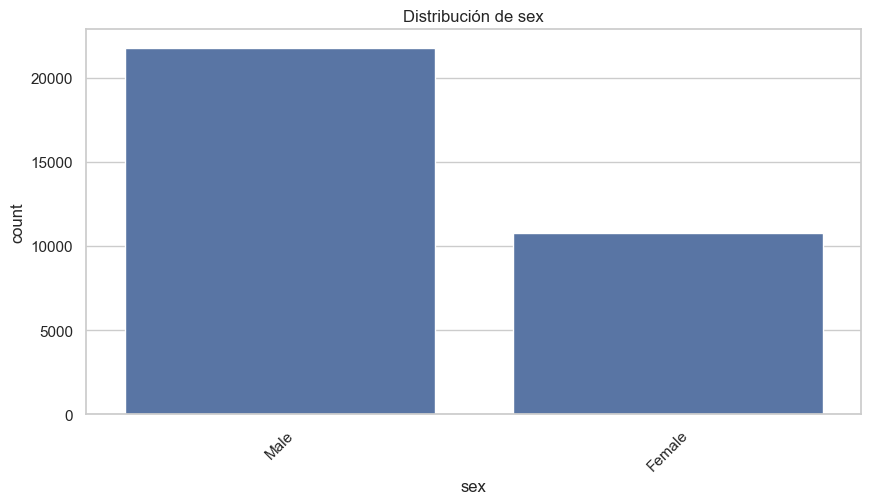

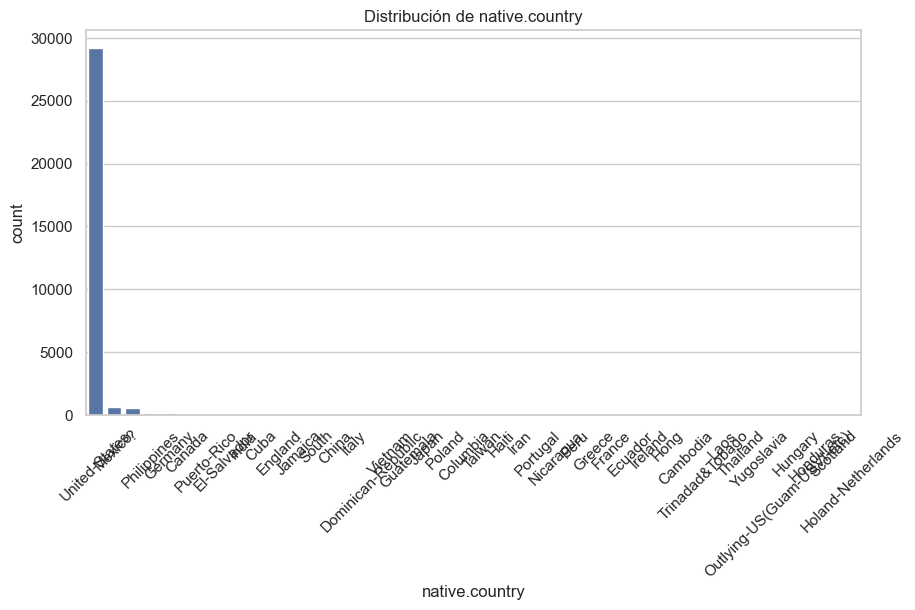

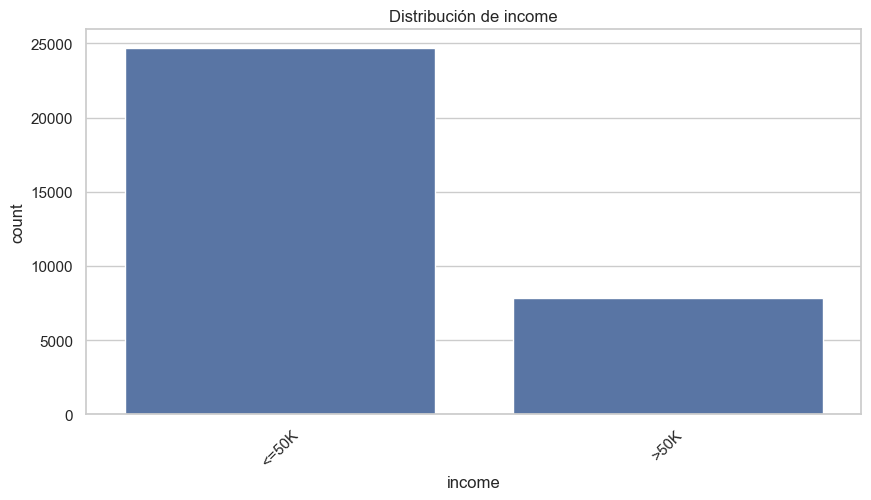

In [19]:
## Distribución de variables categóricas

for column in categorical_columns:

    plt.figure(figsize=(10,5))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )

    plt.xticks(rotation=45)

    plt.title(f"Distribución de {column}")

    plt.show()

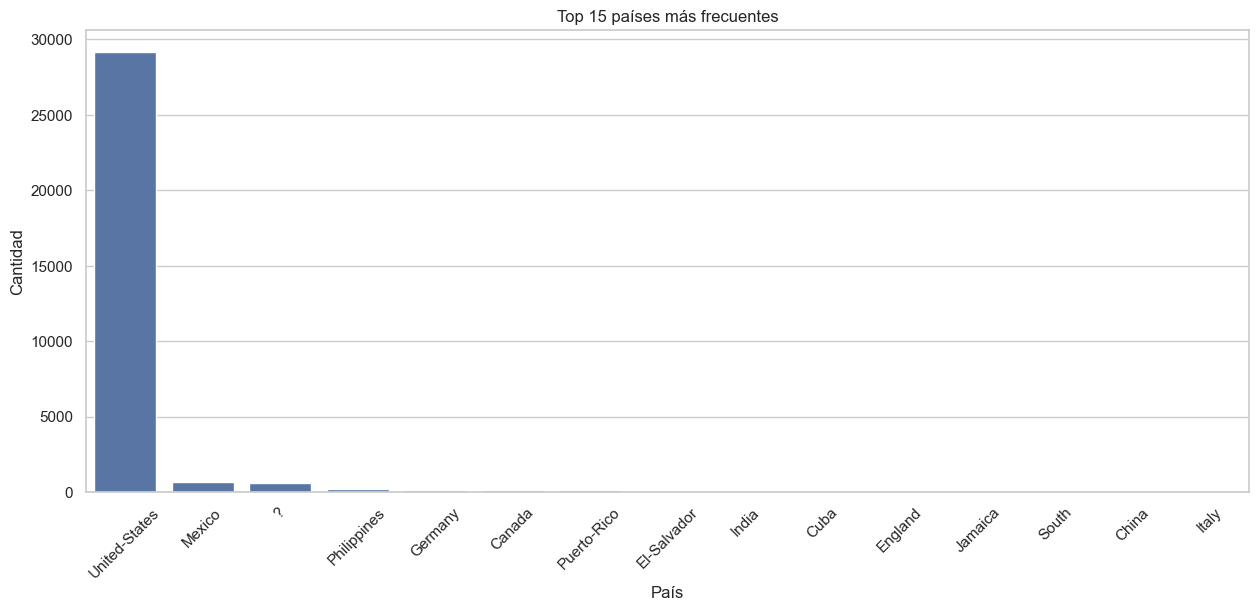

In [20]:
## grafica de natyve.country cambiada ya que la anterior no se ve bien

plt.figure(figsize=(15,6))

top_countries = df["native.country"].value_counts().head(15)

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.xticks(rotation=45)

plt.title("Top 15 países más frecuentes")

plt.xlabel("País")
plt.ylabel("Cantidad")

plt.show()

In [21]:
## Identificación de valores faltantes

df = df.replace("?", np.nan)

In [22]:
## Verificación de valores faltantes

df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     582
income               0
dtype: int64

In [23]:
## Selección actualizada de variables categóricas

categorical_columns = df.select_dtypes(include=['object']).columns

print(categorical_columns)

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='object')


In [24]:
## Selección actualizada de variables numéricas

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

print(numeric_columns)

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')


In [25]:
## Imputación de variables categóricas

categorical_imputer = SimpleImputer(strategy='most_frequent')

df[categorical_columns] = categorical_imputer.fit_transform(df[categorical_columns])

In [26]:
## Imputación de variables numéricas

numeric_imputer = SimpleImputer(strategy='median')

df[numeric_columns] = numeric_imputer.fit_transform(df[numeric_columns])

In [27]:
## Verificación final de valores faltantes

df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

## Codificación y preparación para Machine Learning

In [28]:
## Aplicación de Label Encoding

label_encoders = {}

for column in categorical_columns:

    encoder = LabelEncoder()

    df[column] = encoder.fit_transform(df[column])

    label_encoders[column] = encoder

In [29]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90.0,3,77053.0,11,9.0,6,9,1,4,0,0.0,4356.0,40.0,38,0
1,82.0,3,132870.0,11,9.0,6,3,1,4,0,0.0,4356.0,18.0,38,0
2,66.0,3,186061.0,15,10.0,6,9,4,2,0,0.0,4356.0,40.0,38,0
3,54.0,3,140359.0,5,4.0,0,6,4,4,0,0.0,3900.0,40.0,38,0
4,41.0,3,264663.0,15,10.0,5,9,3,4,0,0.0,3900.0,40.0,38,0


In [30]:
df.dtypes

age               float64
workclass           int32
fnlwgt            float64
education           int32
education.num     float64
marital.status      int32
occupation          int32
relationship        int32
race                int32
sex                 int32
capital.gain      float64
capital.loss      float64
hours.per.week    float64
native.country      int32
income              int32
dtype: object

### Separación de variables predictoras y variable objetivo


In [31]:
## Definición de variables X e y

X = df.drop("income", axis=1)

y = df["income"]

In [32]:
## Verificación de dimensiones

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (32537, 14)
Dimensiones de y: (32537,)


In [33]:
## Visualización de variables predictoras

X.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,90.0,3,77053.0,11,9.0,6,9,1,4,0,0.0,4356.0,40.0,38
1,82.0,3,132870.0,11,9.0,6,3,1,4,0,0.0,4356.0,18.0,38
2,66.0,3,186061.0,15,10.0,6,9,4,2,0,0.0,4356.0,40.0,38
3,54.0,3,140359.0,5,4.0,0,6,4,4,0,0.0,3900.0,40.0,38
4,41.0,3,264663.0,15,10.0,5,9,3,4,0,0.0,3900.0,40.0,38


In [34]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: income, dtype: int32

### Escalado y verificación final del dataset

In [35]:
## Aplicación de StandardScaler

scaler = StandardScaler()

X[numeric_columns] = scaler.fit_transform(X[numeric_columns])

In [36]:
## Verificación del escalado
X.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,3.770003,3,-1.067955,11,-0.420679,6,9,1,4,0,-0.145975,10.589625,-0.035664,38
1,3.183397,3,-0.539159,11,-0.420679,6,3,1,4,0,-0.145975,10.589625,-1.817516,38
2,2.010185,3,-0.035241,15,-0.031815,6,9,4,2,0,-0.145975,10.589625,-0.035664,38
3,1.130276,3,-0.468210,5,-2.364998,0,6,4,4,0,-0.145975,9.458380,-0.035664,38
4,0.177041,3,0.709415,15,-0.031815,5,9,3,4,0,-0.145975,9.458380,-0.035664,38


In [37]:
## Verificación de dimensiones finales

print("Dimensiones finales de X:", X.shape)
print("Dimensiones finales de y:", y.shape)

Dimensiones finales de X: (32537, 14)
Dimensiones finales de y: (32537,)


In [38]:
X.dtypes

age               float64
workclass           int32
fnlwgt            float64
education           int32
education.num     float64
marital.status      int32
occupation          int32
relationship        int32
race                int32
sex                 int32
capital.gain      float64
capital.loss      float64
hours.per.week    float64
native.country      int32
dtype: object

In [39]:
X.describe()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
count,3.253700e+04,32537.000000,3.253700e+04,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,3.253700e+04,3.253700e+04,3.253700e+04,32537.000000
mean,-7.162861e-17,3.094446,-1.262236e-16,10.297507,3.144671e-17,2.611427,6.139288,1.446538,3.665827,0.669238,-2.096447e-17,4.891710e-17,-6.551398e-17,36.419184
std,1.000015e+00,1.107549,1.000015e+00,3.870142,1.000015e+00,1.506301,3.973173,1.607064,0.848847,0.470495,1.000015e+00,1.000015e+00,1.000015e+00,6.053816
min,-1.582777e+00,0.000000,-1.681551e+00,0.000000,-3.531590e+00,0.000000,0.000000,0.000000,0.000000,0.000000,-1.459754e-01,-2.167432e-01,-3.194403e+00,0.000000
25%,-7.761933e-01,3.000000,-6.816726e-01,9.000000,-4.206787e-01,2.000000,3.000000,0.000000,4.000000,0.000000,-1.459754e-01,-2.167432e-01,-3.566374e-02,38.000000
50%,-1.162616e-01,3.000000,-1.082361e-01,11.000000,-3.181473e-02,2.000000,6.000000,1.000000,4.000000,1.000000,-1.459754e-01,-2.167432e-01,-3.566374e-02,38.000000
75%,6.903217e-01,3.000000,4.472760e-01,12.000000,7.459132e-01,4.000000,9.000000,3.000000,4.000000,1.000000,-1.459754e-01,-2.167432e-01,3.693028e-01,38.000000
max,3.770003e+00,7.000000,1.226778e+01,15.000000,2.301369e+00,6.000000,13.000000,5.000000,4.000000,1.000000,1.338964e+01,1.058963e+01,4.742941e+00,40.000000


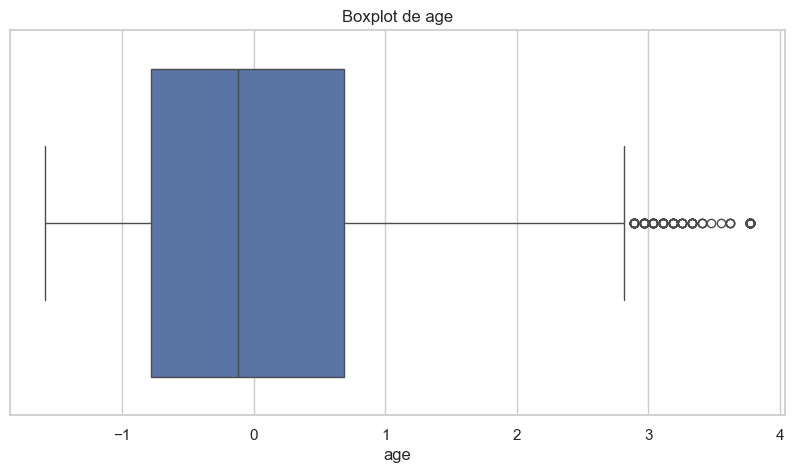

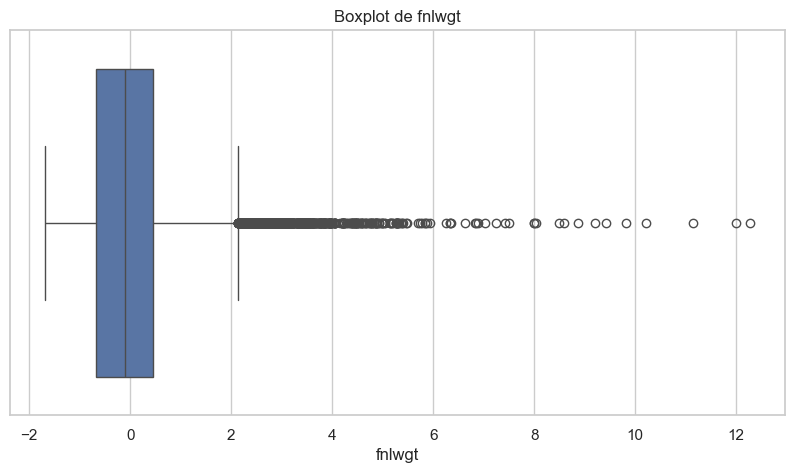

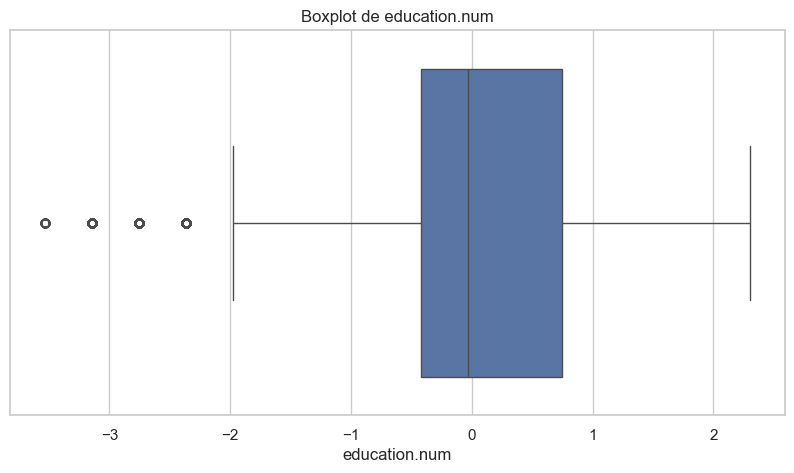

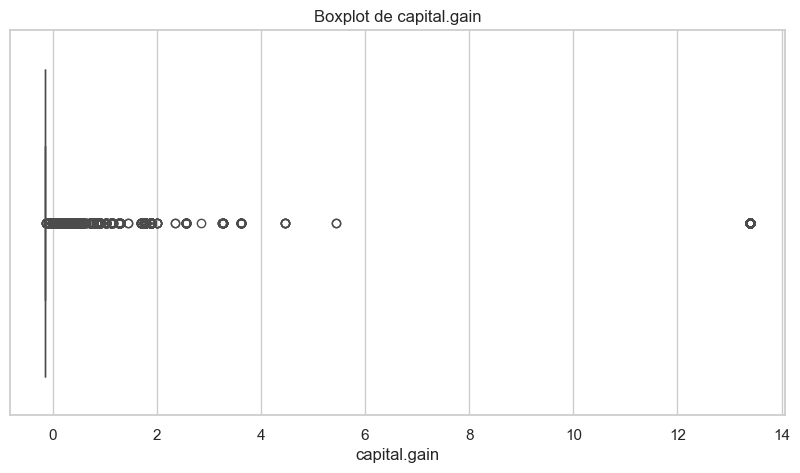

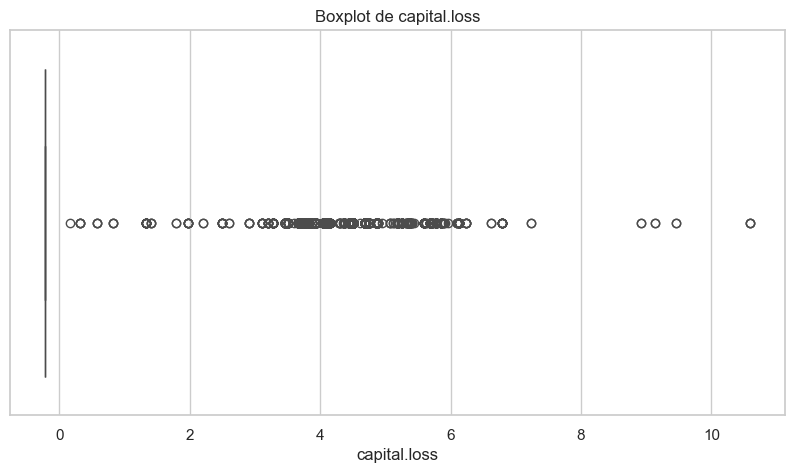

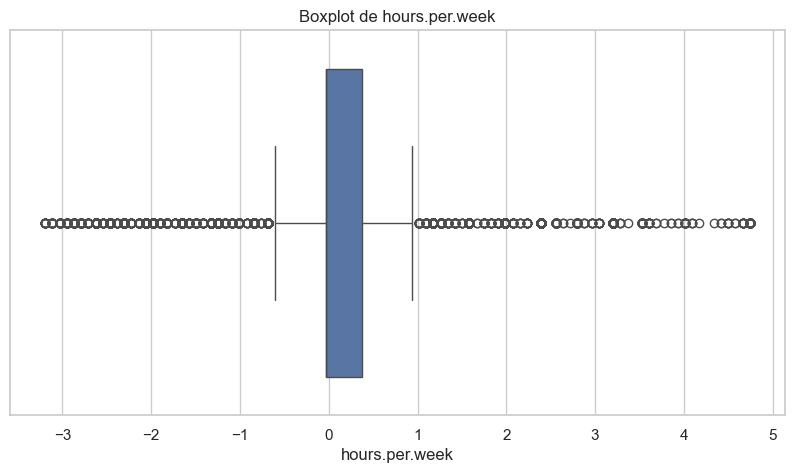

In [40]:
## visualizaciones 

for column in numeric_columns:

    plt.figure(figsize=(10,5))

    sns.boxplot(x=X[column])

    plt.title(f"Boxplot de {column}")

    plt.show()

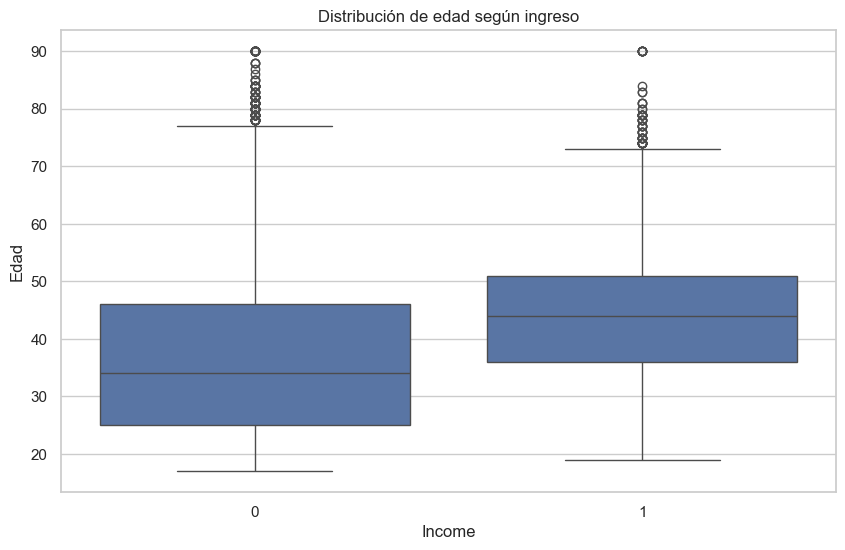

In [41]:
## age vs income

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="income",
    y="age"
)

plt.title("Distribución de edad según ingreso")

plt.xlabel("Income")
plt.ylabel("Edad")

plt.show()

In [42]:
income_labels = {
    0: "<=50K",
    1: ">50K"
}

df["income_label"] = df["income"].map(income_labels)

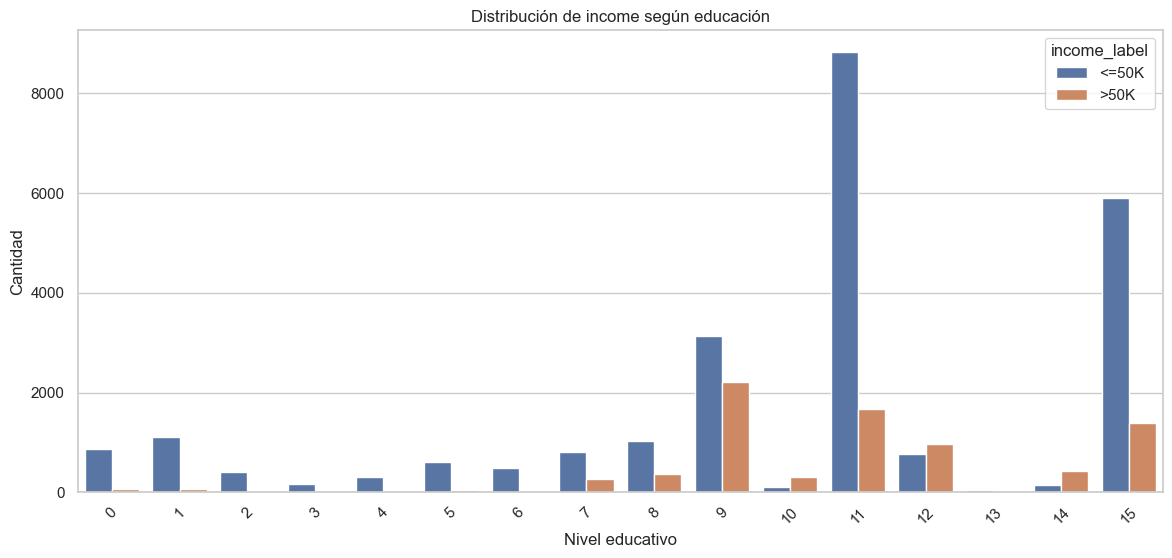

In [43]:
## Education vs Income

plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    x="education",
    hue="income_label"
)

plt.xticks(rotation=45)

plt.title("Distribución de income según educación")

plt.xlabel("Nivel educativo")
plt.ylabel("Cantidad")

plt.show()

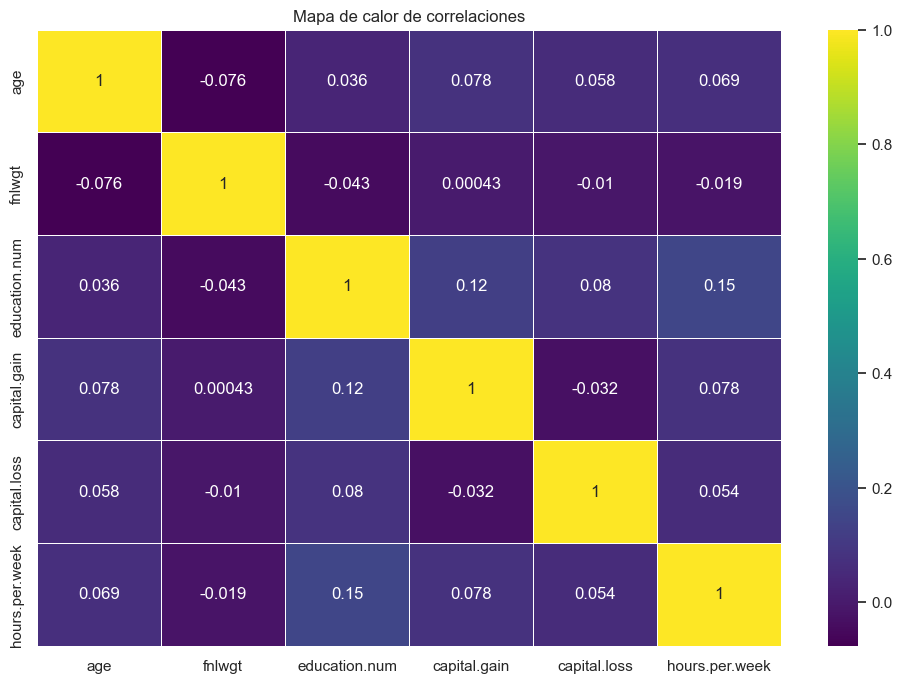

In [44]:
## Heatmap mejorado

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="viridis",
    linewidths=0.5
)

plt.title("Mapa de calor de correlaciones")

plt.show()

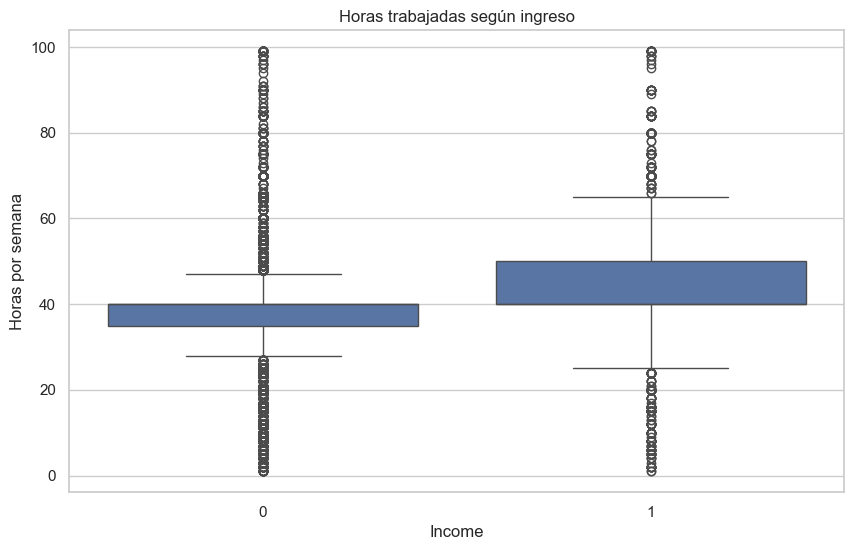

In [45]:
## Hours per week vs Income

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="income",
    y="hours.per.week"
)

plt.title("Horas trabajadas según ingreso")

plt.xlabel("Income")
plt.ylabel("Horas por semana")

plt.show()

# Fase 3 diseño experimental

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X ,
    y ,
    test_size = 0.2 ,
    random_state =42,
    stratify = y
)

In [47]:
# trins y el test
print("X_train:" , X_train.shape)
print("X_test:" , X_test.shape )

print("y_train:" , y_train.shape)
print("y_test:" , y_test.shape )

X_train: (26029, 14)
X_test: (6508, 14)
y_train: (26029,)
y_test: (6508,)


In [48]:
print( y_train.value_counts (normalize=True))

income
0    0.759076
1    0.240924
Name: proportion, dtype: float64


In [49]:
print(y_test.value_counts (normalize=True) )

income
0    0.759066
1    0.240934
Name: proportion, dtype: float64


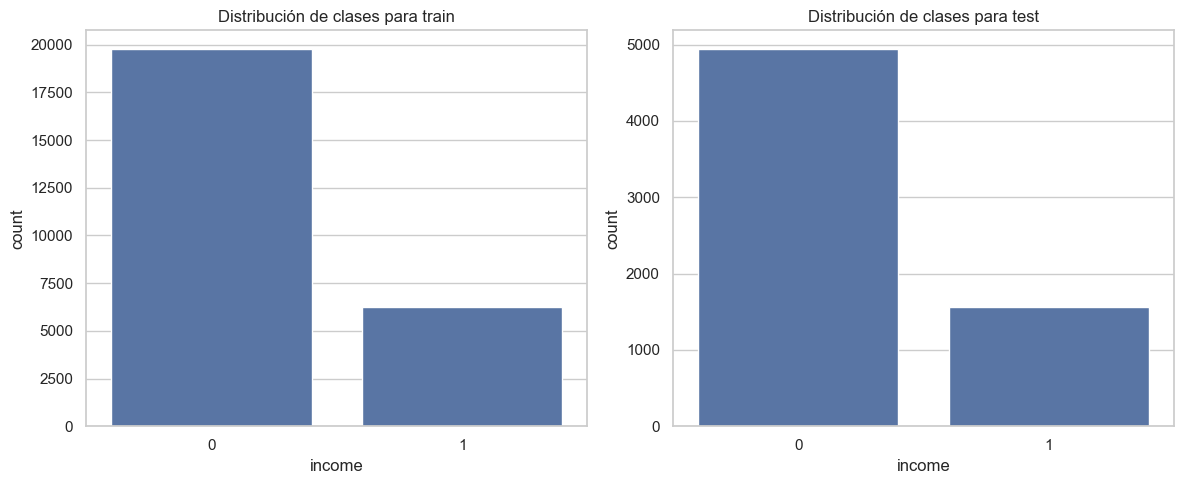

In [50]:
fig, axes = plt.subplots( 1 , 2 ,  figsize = (12 ,5) )

sns.countplot( x=y_train ,   ax=axes[0] )

axes[0].set_title("Distribución de clases para train")

sns.countplot( x=y_test , ax=axes[1] )

axes[1].set_title("Distribución de clases para test" )

plt.tight_layout()

plt.show()

## Simulación para el scenario semi supervisado

In [51]:
# el scenario va a estar con el 5% de etiquetado 
y_train_5 = y_train.copy()

In [52]:
_, X_labeled_5, _, y_labeled_5 = train_test_split(
    X_train, y_train,
    test_size = 0.05 ,
    random_state = 42 ,
    stratify = y_train
)

labeled_indices_5 = X_labeled_5.index

In [53]:
y_train_5.loc[ ~y_train.index.isin(labeled_indices_5) ] = -1

In [54]:
print( y_train_5.value_counts() )

income
-1    24727
 0      988
 1      314
Name: count, dtype: int64


In [55]:
print("Total de los datos etiquetados:" )

print((y_train_5 != -1).sum())

Total de los datos etiquetados:
1302


In [56]:
print("Total de los datos no etiquetados:" )

print((y_train_5 == -1).sum())


Total de los datos no etiquetados:
24727


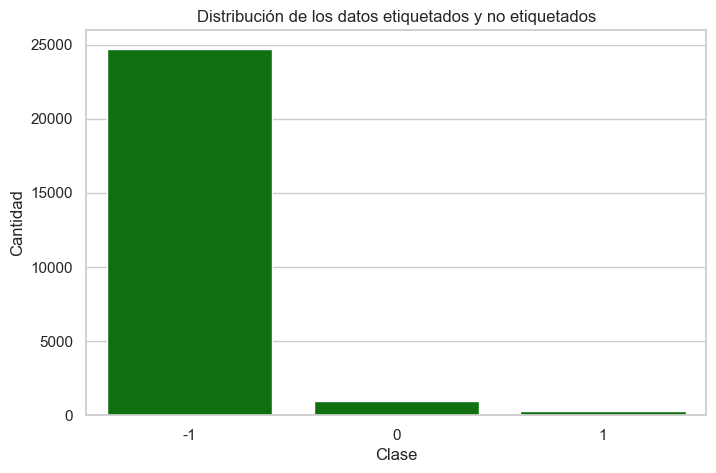

In [57]:
plt.figure(figsize=(8,5))

sns.countplot(x=y_train_5, color="green")

plt.title("Distribución de los datos etiquetados y no etiquetados")

plt.xlabel( "Clase" )
plt.ylabel( "Cantidad" )
plt.show()

In [58]:
def crear_escenario_semi_supervisado(X_train, y_train, porcentaje, random_state=42):
    
    X_labeled, X_unlabeled, y_labeled, y_unlabeled = train_test_split(
        X_train , y_train , train_size = porcentaje , random_state = random_state ,
        stratify =  y_train
    )
    
    y_train_semi =  y_train.copy()
    
    y_train_semi.loc[X_unlabeled.index] =  -1
    
    return y_train_semi

## Evaluar los porcentajes del 5%, 10%, 15%, 20 %, 25%, 30 %

In [59]:
porcentajes = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

escenarios = { }

for p in porcentajes:
    
    y_train_semi = crear_escenario_semi_supervisado( X_train , y_train , p )
    
    escenarios[p] = y_train_semi
    
    print("porcentaje del :" , int(p * 100), "%") 

    print( y_train_semi.value_counts() )
    print()

porcentaje del : 5 %
income
-1    24728
 0      988
 1      313
Name: count, dtype: int64

porcentaje del : 10 %
income
-1    23427
 0     1975
 1      627
Name: count, dtype: int64

porcentaje del : 15 %
income
-1    22125
 0     2963
 1      941
Name: count, dtype: int64

porcentaje del : 20 %
income
-1    20824
 0     3951
 1     1254
Name: count, dtype: int64

porcentaje del : 25 %
income
-1    19522
 0     4939
 1     1568
Name: count, dtype: int64

porcentaje del : 30 %
income
-1    18221
 0     5927
 1     1881
Name: count, dtype: int64



In [60]:
#  preprocesamiento

numeric_features = X_train.select_dtypes( include= ["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include = ["object" , "category" ] ).columns

numeric_transformer = Pipeline(steps=[ ("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()) ])

categorical_transformer = Pipeline(steps=[ ("imputer" , SimpleImputer(strategy="most_frequent") ) , ("encoder" , OneHotEncoder( handle_unknown = "ignore" )) ])


preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_preprocesado = preprocessor.fit_transform(X_train)

X_test_preprocesado = preprocessor.transform(X_test)

## Comparación del modelo supervisado y semi-supervisado

In [61]:
resultados = []

for p in porcentajes:
    
    print("Evaluando el porcentaje del:", int(p * 100), "%")
    
    y_train_semi = escenarios[p ]

    
    mask_labeled = y_train_semi !=  -1
    
    X_train_labeled = X_train_preprocesado[ mask_labeled]
    y_train_labeled = y_train[ mask_labeled]
    
    modelo_supervisado = RandomForestClassifier (
        n_estimators = 100 ,
        random_state = 42 ,
        class_weight = "balanced" )
    
    modelo_supervisado.fit( X_train_labeled , y_train_labeled )
    
    y_pred_supervisado = modelo_supervisado.predict( X_test_preprocesado)
    
    resultados.append(
        {
        "Porcentaje": int(p * 100),
        "modelo": "Supervisado",
        "Accuracy": accuracy_score(y_test, y_pred_supervisado),
        "Precision": precision_score(y_test, y_pred_supervisado, zero_division=0),
        "Recall": recall_score(y_test, y_pred_supervisado, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_supervisado, zero_division=0)
    })
    
    
    
    modelo_base = RandomForestClassifier(
        n_estimators = 100 , random_state = 42 ,
        class_weight = "balanced"
    )
    
    modelo_semi = SelfTrainingClassifier(
        estimator = modelo_base, threshold = 0.75 ,
        criterion = "threshold" , max_iter = 10
    )
    
    modelo_semi.fit(X_train_preprocesado, y_train_semi)
    
    y_pred_semi = modelo_semi.predict(X_test_preprocesado)
    
    resultados.append({
        "Porcentaje": int(p * 100),
        "modelo": "Semi-supervisado",
        "Accuracy": accuracy_score(y_test, y_pred_semi),
        "Precision": precision_score(y_test, y_pred_semi, zero_division=0),
        "Recall": recall_score(y_test, y_pred_semi, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_semi, zero_division=0)
    })

Evaluando el porcentaje del: 5 %
Evaluando el porcentaje del: 10 %
Evaluando el porcentaje del: 15 %
Evaluando el porcentaje del: 20 %
Evaluando el porcentaje del: 25 %
Evaluando el porcentaje del: 30 %


In [62]:
df_resultados = pd.DataFrame(resultados)

df_resultados

,Porcentaje,modelo,Accuracy,Precision,Recall,F1-score
0,5,Supervisado,0.809465,0.645133,0.464923,0.540400
1,5,Semi-supervisado,0.822987,0.711382,0.446429,0.548589
2,10,Supervisado,0.811616,0.652135,0.467474,0.544577
3,10,Semi-supervisado,0.820836,0.705943,0.439413,0.541667
4,15,Supervisado,0.810387,0.647788,0.466837,0.542624
5,15,Semi-supervisado,0.819914,0.686792,0.464286,0.554033
6,20,Supervisado,0.806546,0.631043,0.474490,0.541682
7,20,Semi-supervisado,0.821297,0.703518,0.446429,0.546235
8,25,Supervisado,0.806699,0.632705,0.471301,0.540205
9,25,Semi-supervisado,0.819760,0.696909,0.445791,0.543757


In [63]:
df_resultados.sort_values(
    by=["Porcentaje", "modelo"]
)

,Porcentaje,modelo,Accuracy,Precision,Recall,F1-score
1,5,Semi-supervisado,0.822987,0.711382,0.446429,0.548589
0,5,Supervisado,0.809465,0.645133,0.464923,0.540400
3,10,Semi-supervisado,0.820836,0.705943,0.439413,0.541667
2,10,Supervisado,0.811616,0.652135,0.467474,0.544577
5,15,Semi-supervisado,0.819914,0.686792,0.464286,0.554033
4,15,Supervisado,0.810387,0.647788,0.466837,0.542624
7,20,Semi-supervisado,0.821297,0.703518,0.446429,0.546235
6,20,Supervisado,0.806546,0.631043,0.474490,0.541682
9,25,Semi-supervisado,0.819760,0.696909,0.445791,0.543757
8,25,Supervisado,0.806699,0.632705,0.471301,0.540205


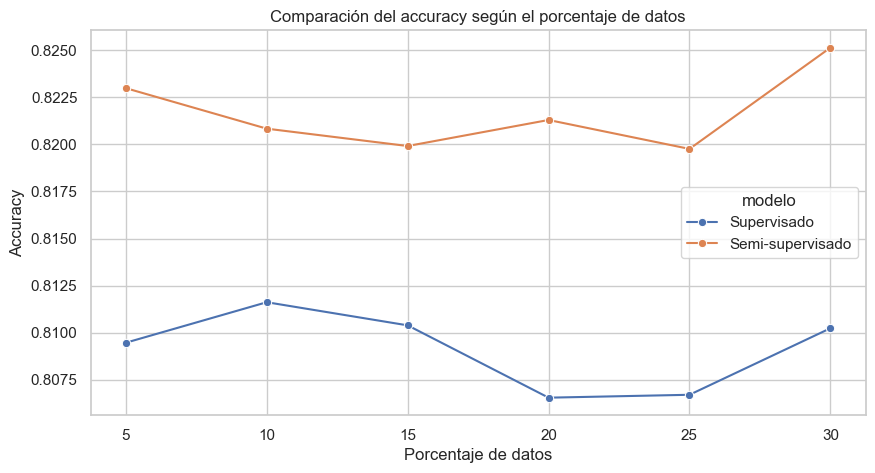

In [64]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data = df_resultados ,
    x = "Porcentaje" ,
    y = "Accuracy" ,
    hue = "modelo" ,
    marker = "o"
)

plt.title("Comparación del accuracy según el porcentaje de datos" )
plt.xlabel("Porcentaje de datos")
plt.ylabel("Accuracy" )
plt.grid(True)
plt.show()

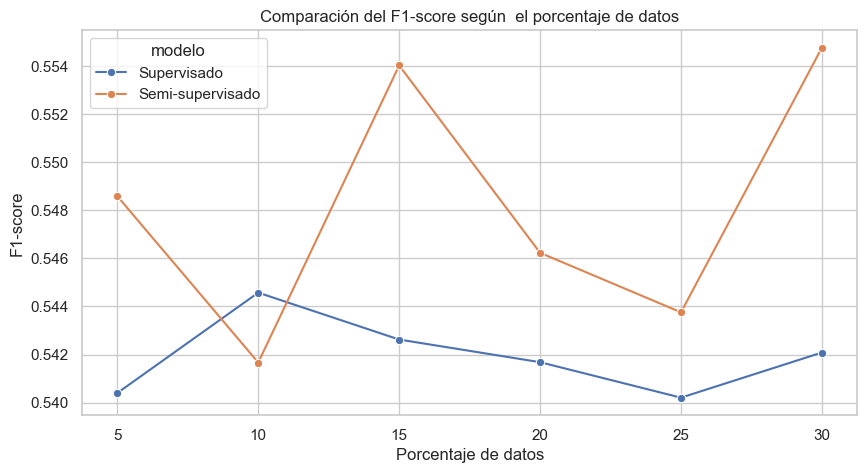

In [65]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data = df_resultados,
    x = "Porcentaje" ,
    y = "F1-score" ,
    hue = "modelo" ,
    marker = "o"
)

plt.title("Comparación del F1-score según  el porcentaje de datos")
plt.xlabel("Porcentaje de datos" )
plt.ylabel("F1-score")
plt.grid(True)
plt.show()

# Fase 4: Experimentación

## 4a. Variación de Hiperparámetros


In [66]:
## Importaciones adicionales para Fase 4 y 5

from sklearn.metrics import roc_auc_score, roc_curve, auc
import itertools
import time
import warnings
warnings.filterwarnings("ignore")

print("Librerías cargadas correctamente")


Librerías cargadas correctamente


### 4a.1 — Variación del Threshold (τ)

In [67]:
## Variación del threshold con 10% de datos etiquetados

thresholds = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
y_train_semi_10 = escenarios[0.10]   # usamos el escenario del 10%

resultados_threshold = []

for tau in thresholds:
    modelo_base = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
    modelo_semi = SelfTrainingClassifier(estimator=modelo_base, threshold=tau, criterion="threshold", max_iter=10)
    modelo_semi.fit(X_train_preprocesado, y_train_semi_10)
    y_pred = modelo_semi.predict(X_test_preprocesado)
    
    resultados_threshold.append({
        "Threshold": tau,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "F1-score":  f1_score(y_test, y_pred, zero_division=0),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
    })

df_threshold = pd.DataFrame(resultados_threshold)
print(df_threshold.to_string(index=False))


 Threshold  Accuracy  F1-score  Precision   Recall
      0.60  0.820375  0.553987   0.689459 0.463010
      0.65  0.821143  0.548837   0.699605 0.451531
      0.70  0.821451  0.541074   0.710581 0.436862
      0.75  0.820836  0.541667   0.705943 0.439413
      0.80  0.823602  0.547675   0.716495 0.443240
      0.85  0.823448  0.544228   0.719832 0.437500
      0.90  0.822065  0.548714   0.705411 0.448980
      0.95  0.817609  0.546774   0.681256 0.456633


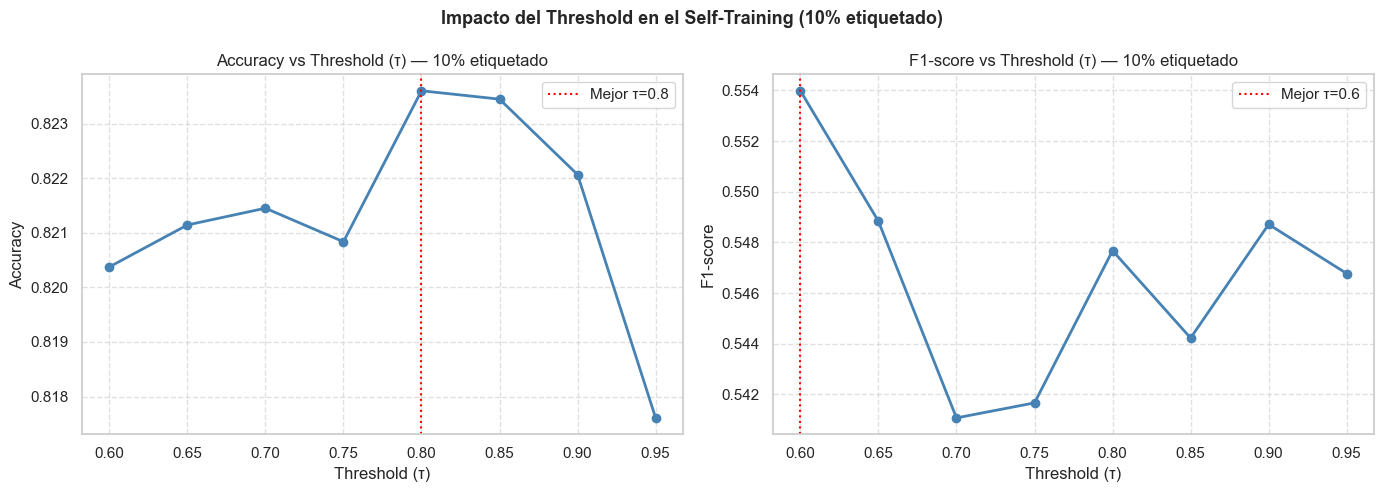

In [68]:
## Gráfico: métricas vs threshold

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ["Accuracy", "F1-score"]):
    ax.plot(df_threshold["Threshold"], df_threshold[metric], marker="o", linewidth=2, color="steelblue")
    ax.set_title(f"{metric} vs Threshold (τ) — 10% etiquetado")
    ax.set_xlabel("Threshold (τ)")
    ax.set_ylabel(metric)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.axvline(df_threshold.loc[df_threshold[metric].idxmax(), "Threshold"], color="red",
               linestyle=":", label=f"Mejor τ={df_threshold.loc[df_threshold[metric].idxmax(),'Threshold']}")
    ax.legend()

plt.suptitle("Impacto del Threshold en el Self-Training (10% etiquetado)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 4a.2 — Variación de n_estimators (número de árboles)

In [69]:
## Variación de n_estimators con threshold=0.75, 10% etiquetado

n_estimators_list = [10, 25, 50, 100, 150, 200]
y_train_semi_10 = escenarios[0.10]

resultados_nestimators = []

for n in n_estimators_list:
    modelo_base = RandomForestClassifier(n_estimators=n, random_state=42, class_weight="balanced")
    modelo_semi = SelfTrainingClassifier(estimator=modelo_base, threshold=0.75, criterion="threshold", max_iter=10)
    modelo_semi.fit(X_train_preprocesado, y_train_semi_10)
    y_pred = modelo_semi.predict(X_test_preprocesado)
    
    resultados_nestimators.append({
        "n_estimators": n,
        "Accuracy":     accuracy_score(y_test, y_pred),
        "F1-score":     f1_score(y_test, y_pred, zero_division=0),
        "Precision":    precision_score(y_test, y_pred, zero_division=0),
        "Recall":       recall_score(y_test, y_pred, zero_division=0),
    })

df_nestimators = pd.DataFrame(resultados_nestimators)
print(df_nestimators.to_string(index=False))


 n_estimators  Accuracy  F1-score  Precision   Recall
           10  0.818992  0.544470   0.691552 0.448980
           25  0.820221  0.552067   0.690613 0.459821
           50  0.823755  0.545743   0.719958 0.439413
          100  0.820836  0.541667   0.705943 0.439413
          150  0.823141  0.543073   0.719243 0.436224
          200  0.823602  0.545886   0.718750 0.440051


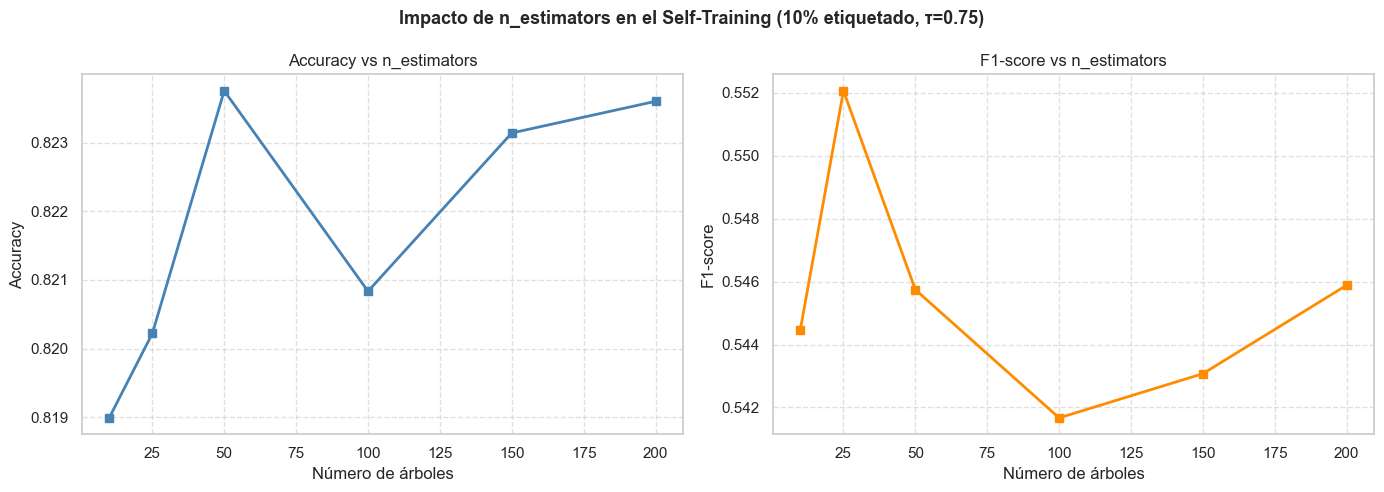

In [70]:
## Gráfico: métricas vs n_estimators

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["steelblue", "darkorange"]
metrics = ["Accuracy", "F1-score"]

for ax, metric, color in zip(axes, metrics, colors):
    ax.plot(df_nestimators["n_estimators"], df_nestimators[metric],
            marker="s", linewidth=2, color=color)
    ax.set_title(f"{metric} vs n_estimators")
    ax.set_xlabel("Número de árboles")
    ax.set_ylabel(metric)
    ax.grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Impacto de n_estimators en el Self-Training (10% etiquetado, τ=0.75)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 4a.3 — Variación de max_iter (iteraciones del Self-Training)

In [71]:
## Variación de max_iter con threshold=0.75, 10% etiquetado

max_iters = [1, 2, 3, 5, 7, 10, 15, 20]
y_train_semi_10 = escenarios[0.10]

resultados_maxiter = []

for mi in max_iters:
    modelo_base = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
    modelo_semi = SelfTrainingClassifier(estimator=modelo_base, threshold=0.75,
                                          criterion="threshold", max_iter=mi)
    modelo_semi.fit(X_train_preprocesado, y_train_semi_10)
    y_pred = modelo_semi.predict(X_test_preprocesado)
    
    resultados_maxiter.append({
        "max_iter":  mi,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "F1-score":  f1_score(y_test, y_pred, zero_division=0),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
    })

df_maxiter = pd.DataFrame(resultados_maxiter)
print(df_maxiter.to_string(index=False))


 max_iter  Accuracy  F1-score  Precision   Recall
        1  0.819146  0.543975   0.692991 0.447704
        2  0.822065  0.545882   0.708758 0.443878
        3  0.824063  0.550098   0.716479 0.446429
        5  0.822219  0.545026   0.710769 0.441964
        7  0.821911  0.543521   0.710608 0.440051
       10  0.820836  0.541667   0.705943 0.439413
       15  0.821604  0.542733   0.709578 0.439413
       20  0.820990  0.541158   0.707518 0.438138


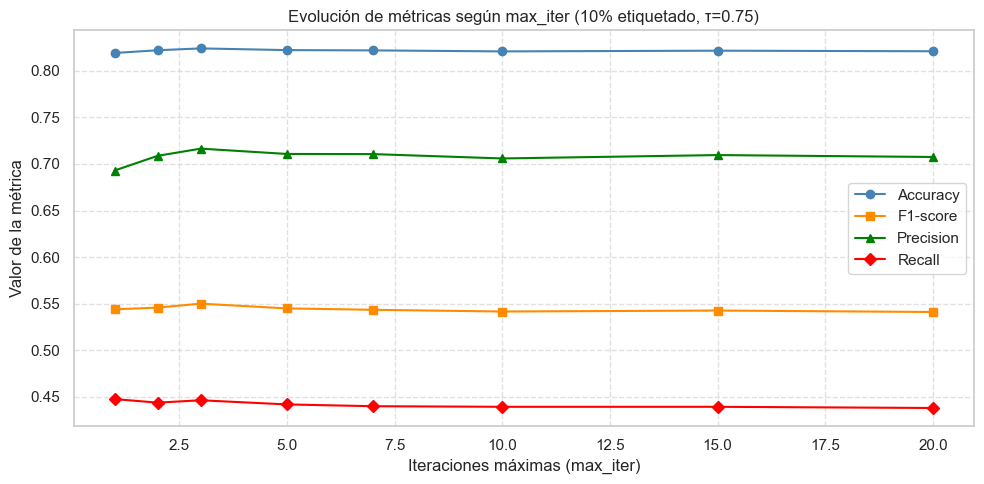

In [72]:
## Gráfico: métricas vs max_iter

plt.figure(figsize=(10, 5))
plt.plot(df_maxiter["max_iter"], df_maxiter["Accuracy"],  marker="o", label="Accuracy",  color="steelblue")
plt.plot(df_maxiter["max_iter"], df_maxiter["F1-score"],  marker="s", label="F1-score",  color="darkorange")
plt.plot(df_maxiter["max_iter"], df_maxiter["Precision"], marker="^", label="Precision", color="green")
plt.plot(df_maxiter["max_iter"], df_maxiter["Recall"],    marker="D", label="Recall",    color="red")

plt.title("Evolución de métricas según max_iter (10% etiquetado, τ=0.75)")
plt.xlabel("Iteraciones máximas (max_iter)")
plt.ylabel("Valor de la métrica")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


## 4b. Evaluación Completa de Métricas

In [73]:
## Evaluación con el mejor threshold encontrado

mejor_tau    = df_threshold.loc[df_threshold["F1-score"].idxmax(), "Threshold"]
mejor_n_est  = df_nestimators.loc[df_nestimators["F1-score"].idxmax(), "n_estimators"]

print(f"Mejor threshold (τ): {mejor_tau}")
print(f"Mejor n_estimators:  {int(mejor_n_est)}")


Mejor threshold (τ): 0.6
Mejor n_estimators:  25


In [74]:
## Evaluación completa de métricas para todos los porcentajes

resultados_full = []

for p in porcentajes:
    y_train_semi = escenarios[p]
    
    # — Supervisado puro (solo datos etiquetados) —
    mask = y_train_semi != -1
    X_lab = X_train_preprocesado[mask]
    y_lab = y_train[mask]
    
    rf_sup = RandomForestClassifier(n_estimators=int(mejor_n_est), random_state=42, class_weight="balanced")
    rf_sup.fit(X_lab, y_lab)
    y_pred_sup  = rf_sup.predict(X_test_preprocesado)
    y_prob_sup  = rf_sup.predict_proba(X_test_preprocesado)[:, 1]
    
    resultados_full.append({
        "Porcentaje": int(p * 100),
        "Modelo":     "Supervisado",
        "Accuracy":   accuracy_score(y_test, y_pred_sup),
        "F1-score":   f1_score(y_test, y_pred_sup, zero_division=0),
        "Precision":  precision_score(y_test, y_pred_sup, zero_division=0),
        "Recall":     recall_score(y_test, y_pred_sup, zero_division=0),
        "AUC-ROC":    roc_auc_score(y_test, y_prob_sup),
    })
    
    # — Semi-supervisado con mejores hiperparámetros —
    rf_base = RandomForestClassifier(n_estimators=int(mejor_n_est), random_state=42, class_weight="balanced")
    clf_semi = SelfTrainingClassifier(estimator=rf_base, threshold=mejor_tau, criterion="threshold", max_iter=10)
    clf_semi.fit(X_train_preprocesado, y_train_semi)
    y_pred_semi = clf_semi.predict(X_test_preprocesado)
    y_prob_semi = clf_semi.predict_proba(X_test_preprocesado)[:, 1]
    
    resultados_full.append({
        "Porcentaje": int(p * 100),
        "Modelo":     "Semi-supervisado",
        "Accuracy":   accuracy_score(y_test, y_pred_semi),
        "F1-score":   f1_score(y_test, y_pred_semi, zero_division=0),
        "Precision":  precision_score(y_test, y_pred_semi, zero_division=0),
        "Recall":     recall_score(y_test, y_pred_semi, zero_division=0),
        "AUC-ROC":    roc_auc_score(y_test, y_prob_semi),
    })

df_full = pd.DataFrame(resultados_full)
print(df_full.to_string(index=False))


 Porcentaje           Modelo  Accuracy  F1-score  Precision   Recall  AUC-ROC
          5      Supervisado  0.799324  0.528179   0.609167 0.466199 0.807211
          5 Semi-supervisado  0.813614  0.547219   0.659766 0.467474 0.744525
         10      Supervisado  0.809773  0.544518   0.643478 0.471939 0.811578
         10 Semi-supervisado  0.819760  0.552119   0.687916 0.461097 0.749888
         15      Supervisado  0.807621  0.541728   0.635739 0.471939 0.814645
         15 Semi-supervisado  0.814843  0.544423   0.668524 0.459184 0.763495
         20      Supervisado  0.804856  0.543494   0.622735 0.482143 0.809309
         20 Semi-supervisado  0.816841  0.551880   0.672161 0.468112 0.770596
         25      Supervisado  0.805163  0.542898   0.624378 0.480230 0.807118
         25 Semi-supervisado  0.813460  0.541541   0.663889 0.457270 0.776436
         30      Supervisado  0.806853  0.544400   0.630563 0.478954 0.803017
         30 Semi-supervisado  0.818685  0.552691   0.681308 0.46

In [75]:
## Tabla pivote de métricas para comparación

for metric in ["Accuracy", "F1-score", "Precision", "Recall", "AUC-ROC"]:
    pivot = df_full.pivot(index="Porcentaje", columns="Modelo", values=metric).round(4)
    pivot["Δ (Semi - Sup)"] = (pivot["Semi-supervisado"] - pivot["Supervisado"]).round(4)
    print(f"\n{'='*55}")
    print(f"  {metric}")
    print('='*55)
    print(pivot.to_string())



  Accuracy
Modelo      Semi-supervisado  Supervisado  Δ (Semi - Sup)
Porcentaje                                               
5                     0.8136       0.7993          0.0143
10                    0.8198       0.8098          0.0100
15                    0.8148       0.8076          0.0072
20                    0.8168       0.8049          0.0119
25                    0.8135       0.8052          0.0083
30                    0.8187       0.8069          0.0118

  F1-score
Modelo      Semi-supervisado  Supervisado  Δ (Semi - Sup)
Porcentaje                                               
5                     0.5472       0.5282          0.0190
10                    0.5521       0.5445          0.0076
15                    0.5444       0.5417          0.0027
20                    0.5519       0.5435          0.0084
25                    0.5415       0.5429         -0.0014
30                    0.5527       0.5444          0.0083

  Precision
Modelo      Semi-supervisado  Super

## 4c. Análisis de Sensibilidad a Hiperparámetros

In [ ]:
## Análisis de sensibilidad: grid de threshold × n_estimators (5% etiquetado)

y_train_semi_5 = escenarios[0.05]

thresholds_grid  = [0.65, 0.75, 0.85, 0.95]
n_estimators_grid = [50, 100, 200]

sens_resultados = []

for tau in thresholds_grid:
    for n in n_estimators_grid:
        rf = RandomForestClassifier(n_estimators=n, random_state=42, class_weight="balanced")
        clf = SelfTrainingClassifier(estimator=rf, threshold=tau, criterion="threshold", max_iter=10)
        clf.fit(X_train_preprocesado, y_train_semi_5)
        y_pred = clf.predict(X_test_preprocesado)
        
        sens_resultados.append({
            "threshold":    tau,
            "n_estimators": n,
            "F1-score":     f1_score(y_test, y_pred, zero_division=0),
            "Accuracy":     accuracy_score(y_test, y_pred),
        })

df_sens = pd.DataFrame(sens_resultados)
print(df_sens.to_string(index=False))


 threshold  n_estimators  F1-score  Accuracy
      0.65            50  0.539877  0.815612
      0.65           100  0.545804  0.818685
      0.65           200  0.549865  0.820375
      0.75            50  0.551697  0.825446
      0.75           100  0.548589  0.822987
      0.75           200  0.544019  0.822526
      0.85            50  0.528892  0.819607
      0.85           100  0.536411  0.820990
      0.85           200  0.533387  0.820682
      0.95            50  0.518101  0.815919
      0.95           100  0.541085  0.818070
      0.95           200  0.533179  0.814075


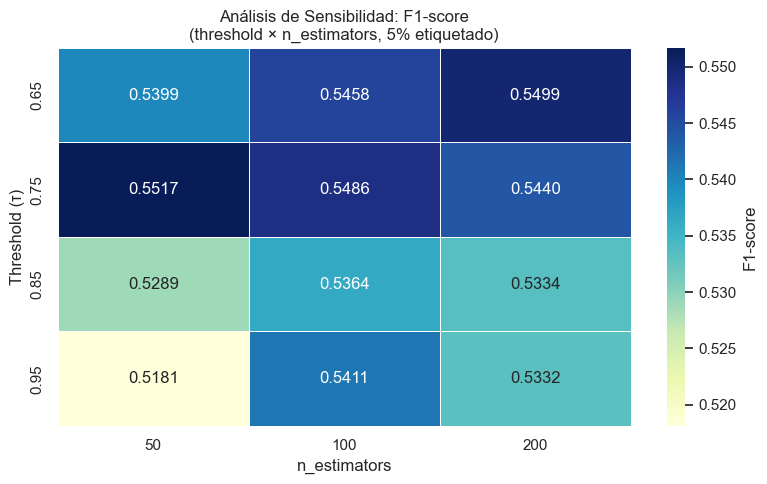

In [77]:
## Heatmap de sensibilidad: F1-score

pivot_f1 = df_sens.pivot(index="threshold", columns="n_estimators", values="F1-score")

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_f1, annot=True, fmt=".4f", cmap="YlGnBu",
            linewidths=0.5, cbar_kws={"label": "F1-score"})
plt.title("Análisis de Sensibilidad: F1-score\n(threshold × n_estimators, 5% etiquetado)")
plt.xlabel("n_estimators")
plt.ylabel("Threshold (τ)")
plt.tight_layout()
plt.show()


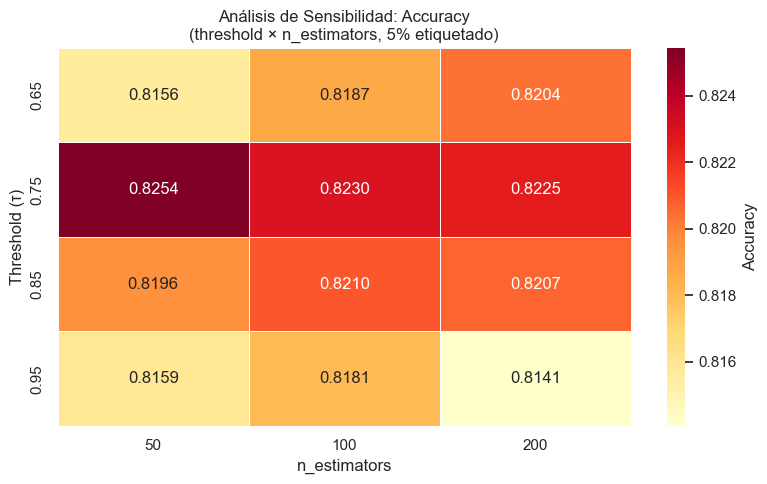

In [78]:
## Heatmap de sensibilidad: Accuracy

pivot_acc = df_sens.pivot(index="threshold", columns="n_estimators", values="Accuracy")

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_acc, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Accuracy"})
plt.title("Análisis de Sensibilidad: Accuracy\n(threshold × n_estimators, 5% etiquetado)")
plt.xlabel("n_estimators")
plt.ylabel("Threshold (τ)")
plt.tight_layout()
plt.show()


In [79]:
## Robustez: variación de métricas entre el 5% y 30% etiquetado

for modelo_nombre in ["Supervisado", "Semi-supervisado"]:
    sub = df_full[df_full["Modelo"] == modelo_nombre]
    rango_f1 = sub["F1-score"].max() - sub["F1-score"].min()
    rango_acc = sub["Accuracy"].max() - sub["Accuracy"].min()
    print(f"\n{modelo_nombre}:")
    print(f"  Rango F1-score  (max - min): {rango_f1:.4f}")
    print(f"  Rango Accuracy  (max - min): {rango_acc:.4f}")
    print("  → Menor rango = más robusto ante variación de etiquetas.")



Supervisado:
  Rango F1-score  (max - min): 0.0163
  Rango Accuracy  (max - min): 0.0104
  → Menor rango = más robusto ante variación de etiquetas.

Semi-supervisado:
  Rango F1-score  (max - min): 0.0112
  Rango Accuracy  (max - min): 0.0063
  → Menor rango = más robusto ante variación de etiquetas.


# Fase 5: Visualización

## 5a. Curvas de Desempeño vs % de Etiquetas

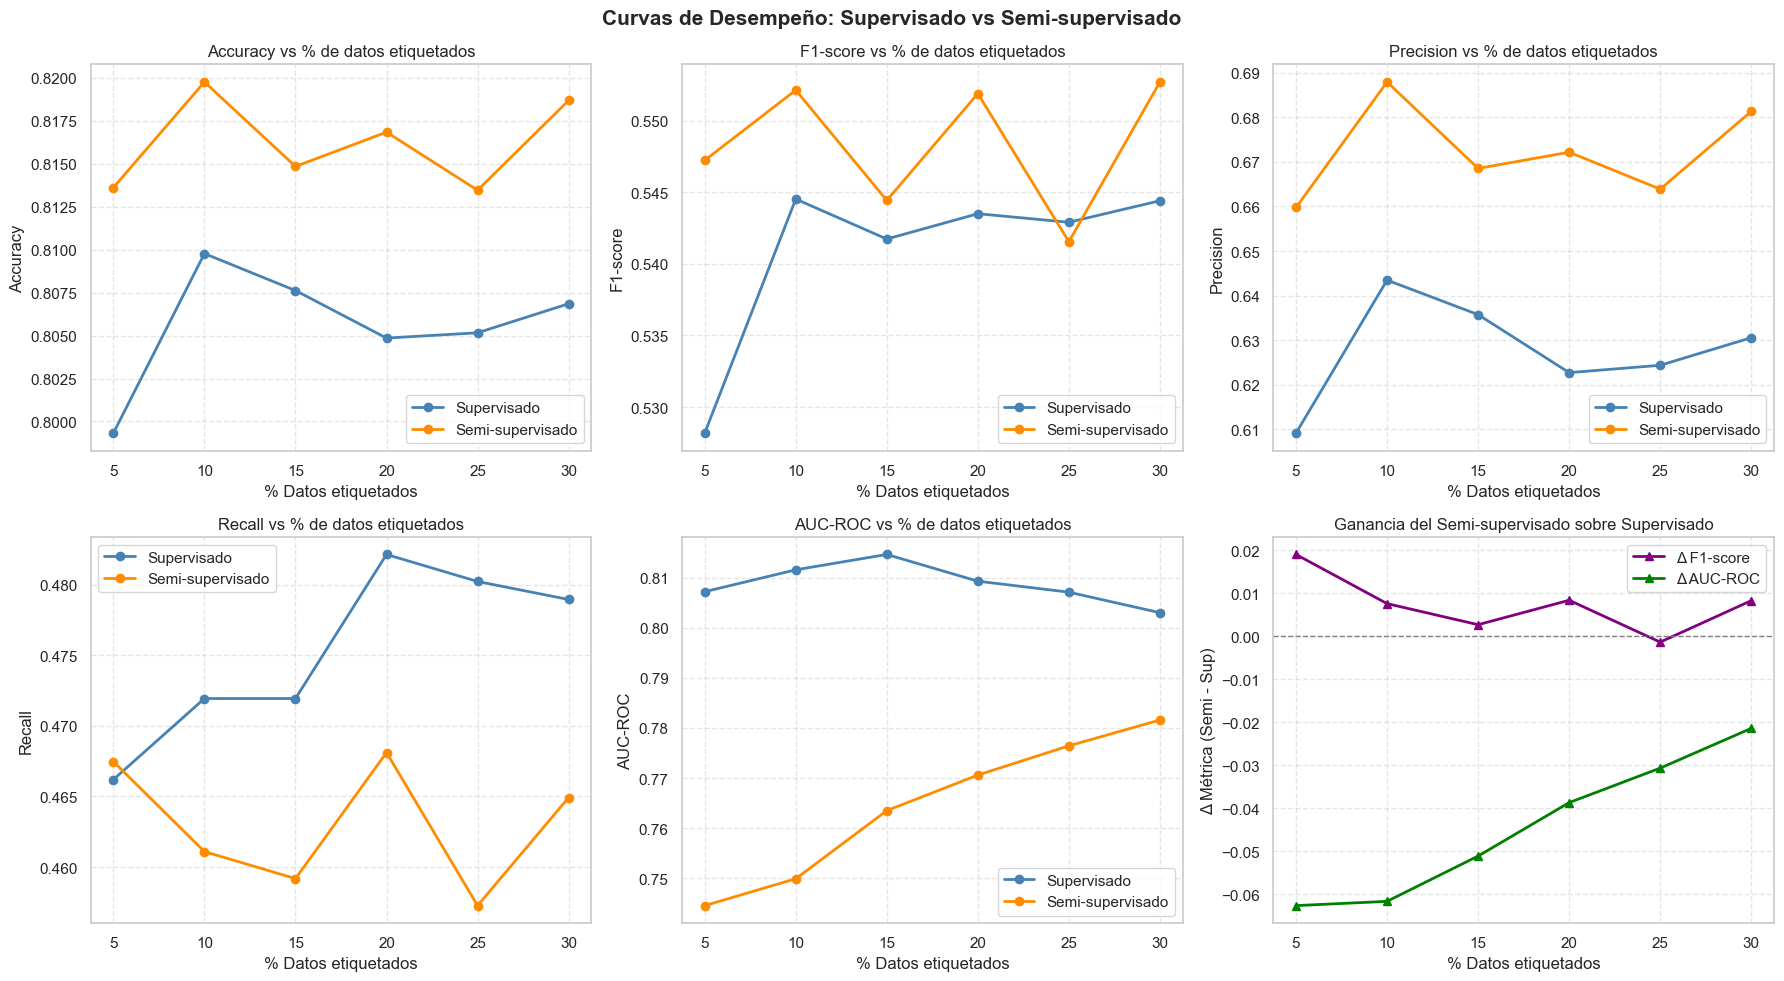

In [80]:
## Curvas de desempeño: todas las métricas vs % etiquetado

metricas = ["Accuracy", "F1-score", "Precision", "Recall", "AUC-ROC"]
colores  = {"Supervisado": "steelblue", "Semi-supervisado": "darkorange"}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metricas):
    ax = axes[i]
    for modelo_nombre, color in colores.items():
        sub = df_full[df_full["Modelo"] == modelo_nombre]
        ax.plot(sub["Porcentaje"], sub[metric], marker="o", label=modelo_nombre,
                color=color, linewidth=2)
    ax.set_title(f"{metric} vs % de datos etiquetados")
    ax.set_xlabel("% Datos etiquetados")
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

# Gráfico de diferencias (ganancia del semi sobre supervisado)
ax = axes[5]
for metric, color in zip(["F1-score", "AUC-ROC"], ["purple", "green"]):
    semi = df_full[df_full["Modelo"]=="Semi-supervisado"][metric].values
    sup  = df_full[df_full["Modelo"]=="Supervisado"][metric].values
    delta = semi - sup
    ax.plot([int(p*100) for p in porcentajes], delta, marker="^", label=f"Δ {metric}",
            linewidth=2, color=color)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Ganancia del Semi-supervisado sobre Supervisado")
ax.set_xlabel("% Datos etiquetados")
ax.set_ylabel("Δ Métrica (Semi - Sup)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Curvas de Desempeño: Supervisado vs Semi-supervisado", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


## 5b. Matrices de Confusión

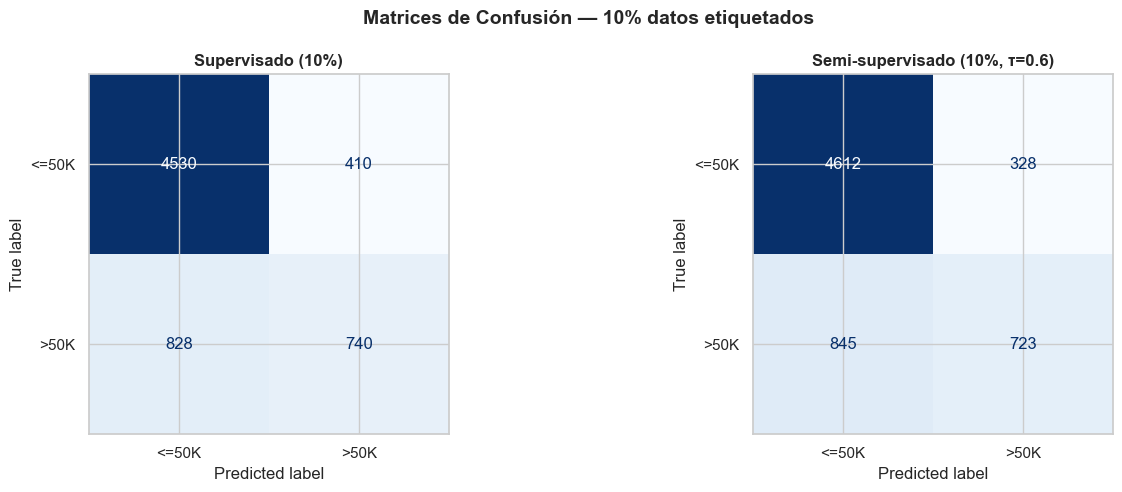

In [81]:
## Matrices de confusión — 10% etiquetado

y_train_semi_10 = escenarios[0.10]
mask = y_train_semi_10 != -1

# Supervisado
rf_sup = RandomForestClassifier(n_estimators=int(mejor_n_est), random_state=42, class_weight="balanced")
rf_sup.fit(X_train_preprocesado[mask], y_train[mask])
y_pred_sup_10 = rf_sup.predict(X_test_preprocesado)

# Semi-supervisado
rf_base = RandomForestClassifier(n_estimators=int(mejor_n_est), random_state=42, class_weight="balanced")
clf_semi_10 = SelfTrainingClassifier(estimator=rf_base, threshold=mejor_tau, criterion="threshold", max_iter=10)
clf_semi_10.fit(X_train_preprocesado, y_train_semi_10)
y_pred_semi_10 = clf_semi_10.predict(X_test_preprocesado)

class_names = ["<=50K", ">50K"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, titulo in zip(axes,
                               [y_pred_sup_10, y_pred_semi_10],
                               ["Supervisado (10%)", f"Semi-supervisado (10%, τ={mejor_tau})"]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(titulo, fontsize=12, fontweight="bold")

plt.suptitle("Matrices de Confusión — 10% datos etiquetados", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


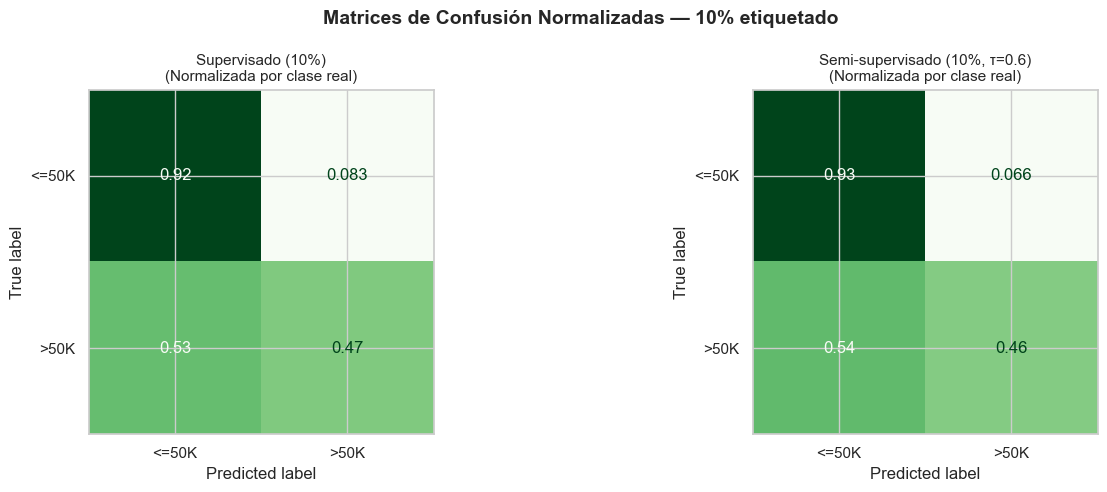

In [82]:
## Matrices de confusión normalizadas (proporción de clase)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, titulo in zip(axes,
                               [y_pred_sup_10, y_pred_semi_10],
                               ["Supervisado (10%)", f"Semi-supervisado (10%, τ={mejor_tau})"]):
    cm_norm = confusion_matrix(y_test, y_pred, normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Greens", colorbar=False)
    ax.set_title(f"{titulo}\n(Normalizada por clase real)", fontsize=11)

plt.suptitle("Matrices de Confusión Normalizadas — 10% etiquetado", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 5c. Curvas ROC

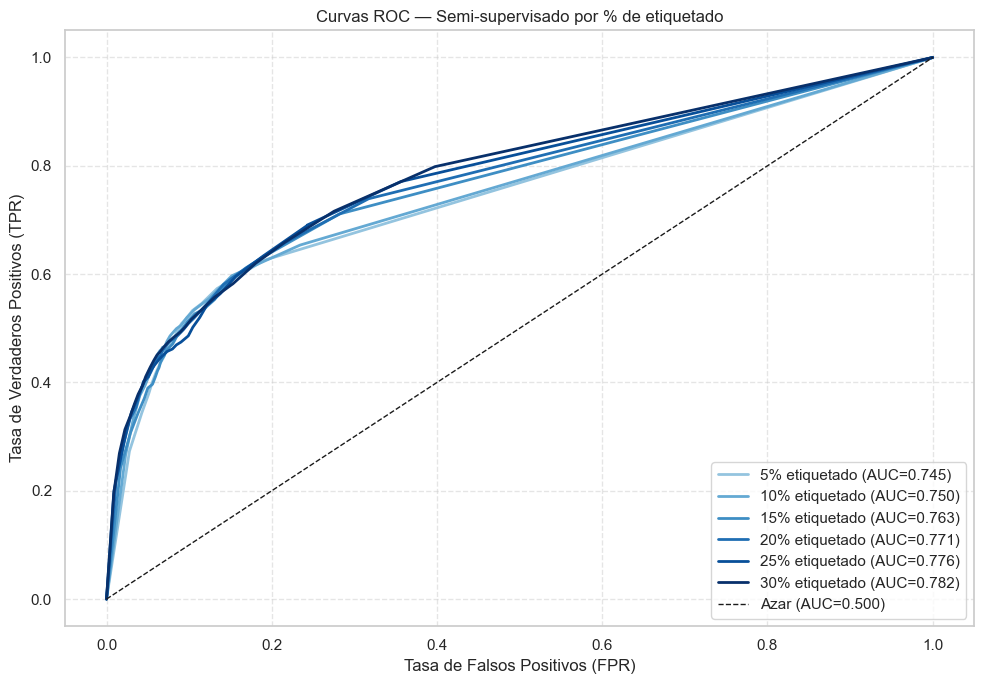

In [83]:
## Curvas ROC — comparación de todos los porcentajes (semi-supervisado)

plt.figure(figsize=(10, 7))

palette = plt.cm.Blues(np.linspace(0.4, 1.0, len(porcentajes)))

for p, color in zip(porcentajes, palette):
    y_train_semi = escenarios[p]
    rf = RandomForestClassifier(n_estimators=int(mejor_n_est), random_state=42, class_weight="balanced")
    clf = SelfTrainingClassifier(estimator=rf, threshold=mejor_tau, criterion="threshold", max_iter=10)
    clf.fit(X_train_preprocesado, y_train_semi)
    y_prob = clf.predict_proba(X_test_preprocesado)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f"{int(p*100)}% etiquetado (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1], "k--", linewidth=1, label="Azar (AUC=0.500)")
plt.title("Curvas ROC — Semi-supervisado por % de etiquetado")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


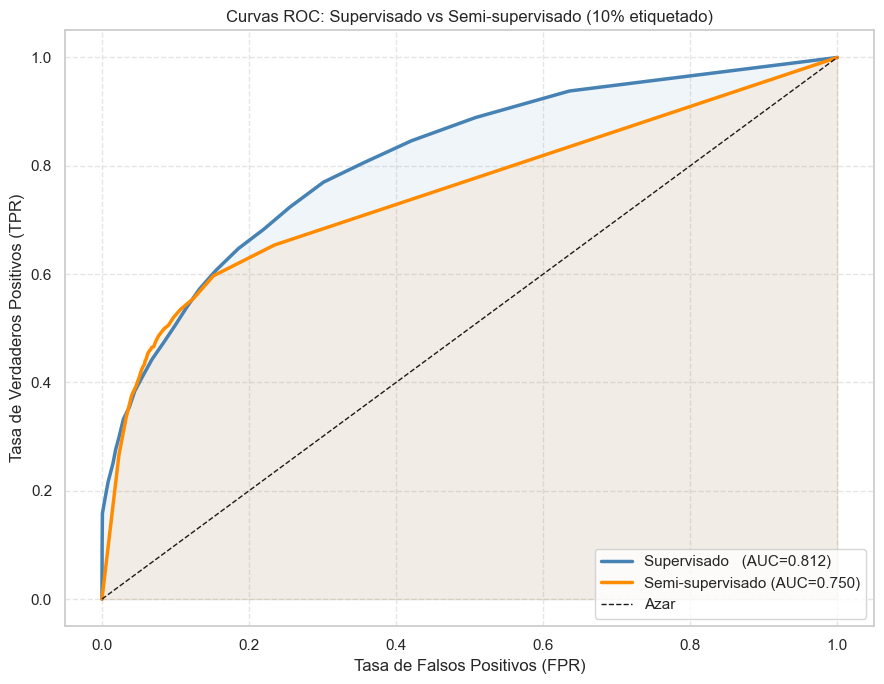

In [84]:
## Curva ROC: Supervisado vs Semi-supervisado (10%)

plt.figure(figsize=(9, 7))

# Supervisado
rf_s = RandomForestClassifier(n_estimators=int(mejor_n_est), random_state=42, class_weight="balanced")
rf_s.fit(X_train_preprocesado[mask], y_train[mask])
y_prob_s = rf_s.predict_proba(X_test_preprocesado)[:, 1]
fpr_s, tpr_s, _ = roc_curve(y_test, y_prob_s)
plt.plot(fpr_s, tpr_s, color="steelblue", linewidth=2.5,
         label=f"Supervisado   (AUC={auc(fpr_s,tpr_s):.3f})")

# Semi-supervisado
rf_b = RandomForestClassifier(n_estimators=int(mejor_n_est), random_state=42, class_weight="balanced")
clf_ss = SelfTrainingClassifier(estimator=rf_b, threshold=mejor_tau, criterion="threshold", max_iter=10)
clf_ss.fit(X_train_preprocesado, y_train_semi_10)
y_prob_ss = clf_ss.predict_proba(X_test_preprocesado)[:, 1]
fpr_ss, tpr_ss, _ = roc_curve(y_test, y_prob_ss)
plt.plot(fpr_ss, tpr_ss, color="darkorange", linewidth=2.5,
         label=f"Semi-supervisado (AUC={auc(fpr_ss,tpr_ss):.3f})")

plt.plot([0,1],[0,1], "k--", linewidth=1, label="Azar")
plt.fill_between(fpr_s, tpr_s, alpha=0.08, color="steelblue")
plt.fill_between(fpr_ss, tpr_ss, alpha=0.08, color="darkorange")

plt.title("Curvas ROC: Supervisado vs Semi-supervisado (10% etiquetado)")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## 5d. Predicción vs Valor Real

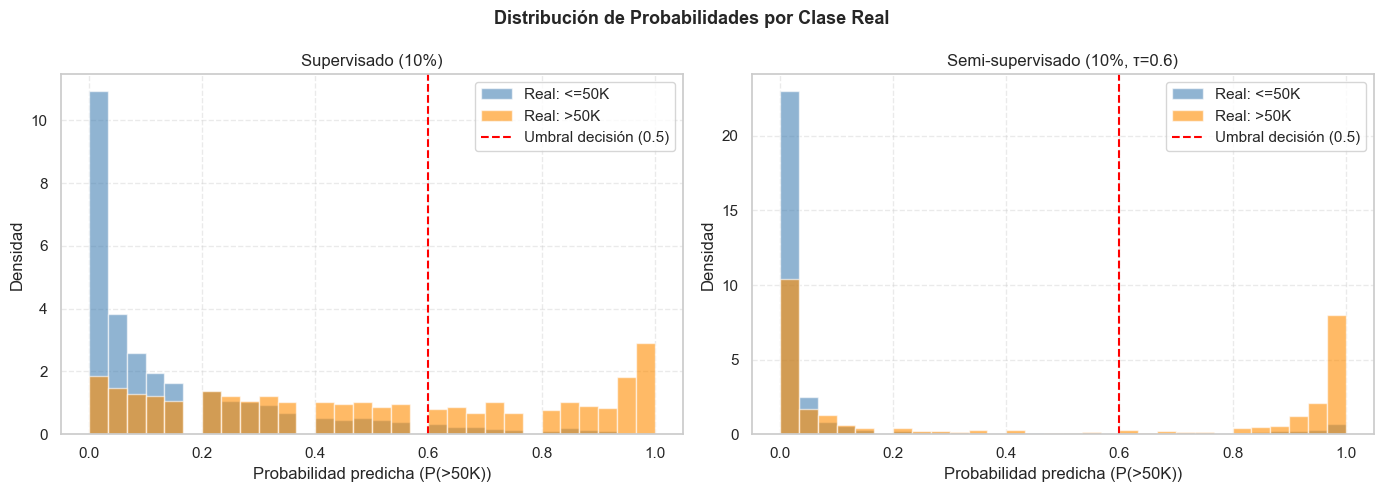

In [85]:
## Visualización: predicción vs valor real — distribución de probabilidades

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

titulos = ["Supervisado (10%)", f"Semi-supervisado (10%, τ={mejor_tau})"]
probs   = [y_prob_s, y_prob_ss]
colores_clases = {0: "steelblue", 1: "darkorange"}

for ax, prob, titulo in zip(axes, probs, titulos):
    for clase, color in colores_clases.items():
        mask_clase = y_test == clase
        ax.hist(prob[mask_clase], bins=30, alpha=0.6, color=color,
                label=f"Real: {'<=50K' if clase==0 else '>50K'}", density=True)
    ax.axvline(mejor_tau, color="red", linestyle="--", label=f"Umbral decisión (0.5)")
    ax.set_title(titulo)
    ax.set_xlabel("Probabilidad predicha (P(>50K))")
    ax.set_ylabel("Densidad")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Distribución de Probabilidades por Clase Real", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


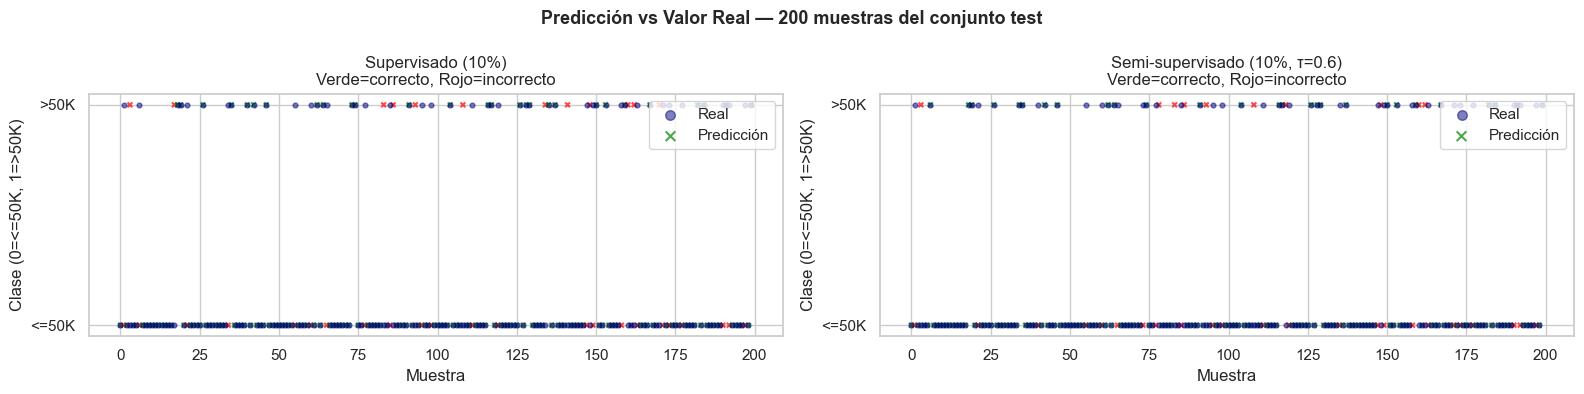

In [86]:
## Predicción vs Real: muestra de 200 observaciones del test

np.random.seed(42)
sample_idx = np.random.choice(len(y_test), 200, replace=False)
y_test_sample   = np.array(y_test)[sample_idx]
y_pred_sup_s    = y_pred_sup_10[sample_idx]
y_pred_semi_s   = y_pred_semi_10[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, y_pred, titulo in zip(axes, [y_pred_sup_s, y_pred_semi_s], titulos):
    correcto = (y_pred == y_test_sample)
    color    = np.where(correcto, "green", "red")
    ax.scatter(range(200), y_test_sample, c="navy", s=12, zorder=3, label="Real", alpha=0.5)
    ax.scatter(range(200), y_pred,        c=color,   s=12, zorder=2, label="Predicción", alpha=0.7, marker="x")
    ax.set_title(f"{titulo}\nVerde=correcto, Rojo=incorrecto")
    ax.set_xlabel("Muestra")
    ax.set_ylabel("Clase (0=<=50K, 1=>50K)")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["<=50K", ">50K"])
    ax.legend(loc="upper right", markerscale=2)

plt.suptitle("Predicción vs Valor Real — 200 muestras del conjunto test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 5e. Gráficos Adicionales

### Feature Importance del mejor modelo Semi-supervisado

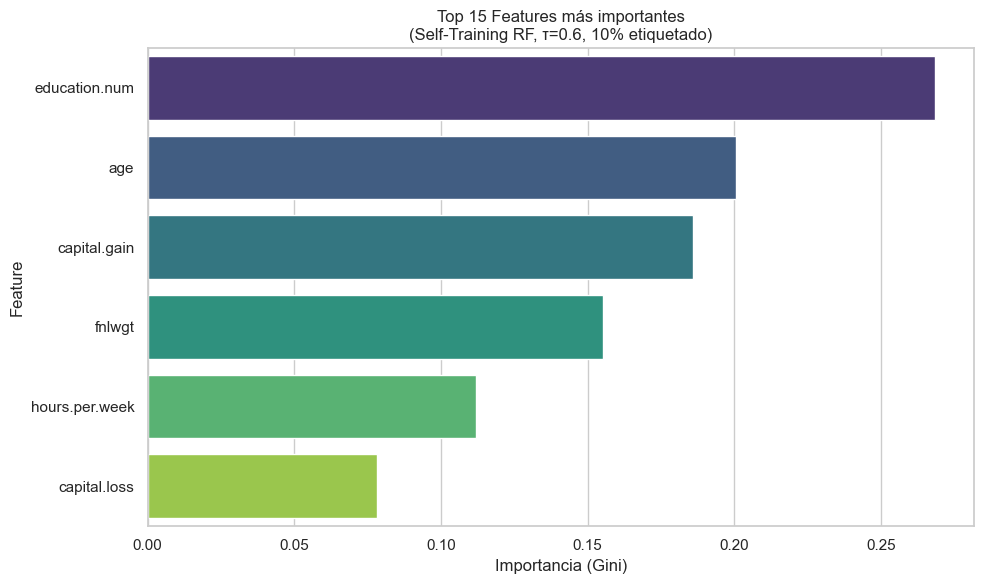

In [87]:
## Feature importance del Random Forest dentro del SelfTraining

# Extraer el estimador base ya entrenado
rf_trained = clf_semi_10.estimator_

feature_names_num = list(X_train.select_dtypes(include=["int64", "float64"]).columns)
feature_names_cat = []
ohe = preprocessor.named_transformers_["cat"]["encoder"]
for i, col in enumerate(X_train.select_dtypes(include=["object", "category"]).columns):
    feature_names_cat.extend([f"{col}_{c}" for c in ohe.categories_[i]])

all_features = feature_names_num + feature_names_cat
importances  = rf_trained.feature_importances_

if len(all_features) != len(importances):
    all_features = [f"Feature {i}" for i in range(len(importances))]

feat_df = pd.DataFrame({"Feature": all_features, "Importance": importances})
feat_df = feat_df.sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")
plt.title(f"Top 15 Features más importantes\n(Self-Training RF, τ={mejor_tau}, 10% etiquetado)")
plt.xlabel("Importancia (Gini)")
plt.tight_layout()
plt.show()


### Resumen Final de Resultados

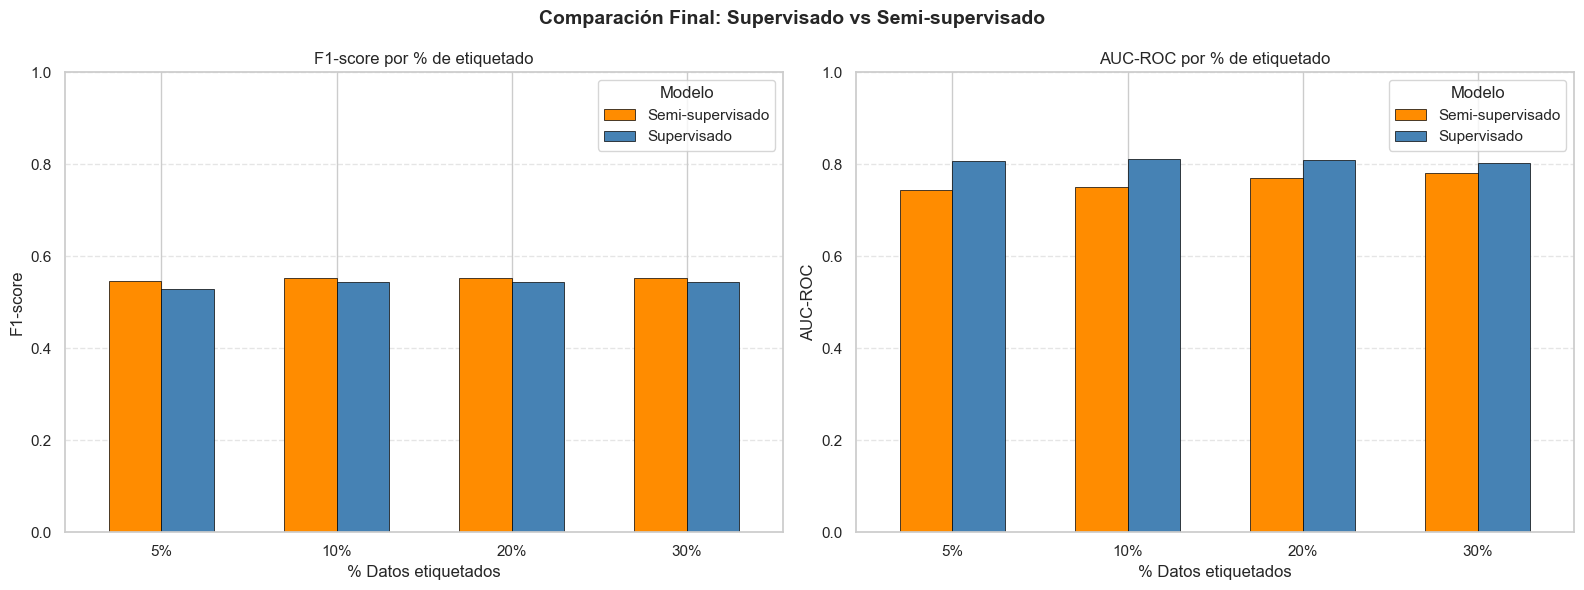


=== TABLA RESUMEN FINAL ===
 Porcentaje           Modelo  Accuracy  F1-score  Precision   Recall  AUC-ROC
          5      Supervisado  0.799324  0.528179   0.609167 0.466199 0.807211
          5 Semi-supervisado  0.813614  0.547219   0.659766 0.467474 0.744525
         10      Supervisado  0.809773  0.544518   0.643478 0.471939 0.811578
         10 Semi-supervisado  0.819760  0.552119   0.687916 0.461097 0.749888
         20      Supervisado  0.804856  0.543494   0.622735 0.482143 0.809309
         20 Semi-supervisado  0.816841  0.551880   0.672161 0.468112 0.770596
         30      Supervisado  0.806853  0.544400   0.630563 0.478954 0.803017
         30 Semi-supervisado  0.818685  0.552691   0.681308 0.464923 0.781588


In [88]:
## Resumen final: tabla comparativa y gráfico de barras agrupado

# Filtrar el escenario del 10% y 20%
df_resumen = df_full[df_full["Porcentaje"].isin([5, 10, 20, 30])].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
metricas_resumen = ["F1-score", "AUC-ROC"]
palette = {"Supervisado": "steelblue", "Semi-supervisado": "darkorange"}

for ax, metric in zip(axes, metricas_resumen):
    sub = df_resumen.pivot(index="Porcentaje", columns="Modelo", values=metric)
    sub.plot(kind="bar", ax=ax, color=[palette[c] for c in sub.columns],
             edgecolor="black", linewidth=0.5, width=0.6)
    ax.set_title(f"{metric} por % de etiquetado")
    ax.set_xlabel("% Datos etiquetados")
    ax.set_ylabel(metric)
    ax.set_xticklabels([f"{v}%" for v in [5, 10, 20, 30]], rotation=0)
    ax.legend(title="Modelo")
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.set_ylim(0, 1)

plt.suptitle("Comparación Final: Supervisado vs Semi-supervisado", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n=== TABLA RESUMEN FINAL ===")
print(df_full[df_full["Porcentaje"].isin([5, 10, 20, 30])].to_string(index=False))
